In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from vivarium import Artifact, InteractiveContext
import pandas as pd, numpy as np, os

In [2]:
!whoami
!date

zmbc


Tue Jun 16 13:13:16 PDT 2026


In [3]:
# Known deviations, multiplicative space
DEVIATION_DUE_TO_IFA_LBWSG_MISCALIBRATION = 0.03 # The IFA shifts on birthweight and gestational age change the population distribution of LBWSG RRs
DEVIATION_DUE_TO_IFA_PRETERM_MISCALIBRATION = 0.05 # The IFA shifts on gestational age change the population prevalence of preterm
DEVIATION_DUE_TO_LNN_CPAP_PAF_NOT_BEING_AGE_SPECIFIC = 0.02 # In LNN, the CPAP PAF does not take into account distribution shifts due to ENN mortality

# V&V neonatal mortality in an interactive simulation

General approach:
* Check quantities subject to stochastic uncertainty both visually and with a statistical test
* Single draw, location, and scenario (baseline)
* Only test relative to artifact, because GBD shared functions can't be directly used in the sim environment -- **this notebook will not find issues in artifact creation**

In [4]:
%pip list | grep vivarium

vivarium                                 4.0.2
vivarium_build_utils                     2.3.8
vivarium_cluster_tools                   3.0.0
vivarium_dependencies                    1.0.7
vivarium_gates_mncnh                     33.1.dev3+gfb9a80fb8 /mnt/share/homes/zmbc/src/vivarium_gates_mncnh
vivarium_public_health                   5.0.1
vivarium_testing_utils                   0.5.1


Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip freeze | grep vivarium

vivarium==4.0.2
vivarium_build_utils==2.3.8
vivarium_cluster_tools==3.0.0
vivarium_dependencies==1.0.7
-e git+https://github.com/ihmeuw/vivarium_gates_mncnh.git@2c8258287ab8b89f20c9a27f07327fc6ac7b34b8#egg=vivarium_gates_mncnh
vivarium_public_health==5.0.1
vivarium_testing_utils==0.5.1


Note: you may need to restart the kernel to use updated packages.


In [6]:
! cat /mnt/share/homes/zmbc/src/vivarium_gates_mncnh/.git/HEAD

ref: refs/heads/more_neonatal_mortality_vv


In [7]:
draw_num = 60

In [8]:
from pathlib import Path

In [9]:
import vivarium_gates_mncnh
from vivarium.framework.configuration import build_model_specification

main_sim_model_specification = build_model_specification(
    Path(vivarium_gates_mncnh.__file__).parent / 'model_specifications/model_spec.yaml'
)
del main_sim_model_specification.configuration.observers

main_sim_model_specification.configuration.input_data.input_draw_number = draw_num
# To get exactly the same randomness as a corresponding psimulate, uncomment the following
# main_sim_model_specification.configuration.randomness.random_seed = 5616 # This isn't documented since it is auto-generated within psimulate from the branches file
# main_sim_model_specification.configuration.randomness.update({'additional_seed': draw_num})
# main_sim_model_specification.configuration.population.population_size = 20_000

# Uncomment this line to run a very large version of this test (takes on the order of 3 hours to run this notebook)
main_sim_model_specification.configuration.population.population_size = 10_000_000

In [10]:
paf_sim_model_specification = build_model_specification(
    Path(vivarium_gates_mncnh.__file__).parent / 'data/lbwsg_paf/code/lbwsg_paf.yaml'
)
# Don't delete observers since we use these to get the PAFs
paf_sim_model_specification.configuration.input_data.input_draw_number = draw_num
# paf_sim_model_specification.configuration.population.population_size = (
#     400**2 # 400x400 grid on gestational age and birth weight...
#     * 58 # ... in each LBWSG category
#     * 2 # ... for each sex
# )

In [11]:
location = "Ethiopia"

In [12]:
orig_location = Path(main_sim_model_specification.configuration.input_data.artifact_path).stem
assert orig_location == Path(paf_sim_model_specification.configuration.input_data.artifact_path).stem
orig_location

'ethiopia'

In [13]:
main_sim_model_specification.configuration.input_data.artifact_path = main_sim_model_specification.configuration.input_data.artifact_path.replace(orig_location, location.lower())
assert Path(main_sim_model_specification.configuration.input_data.artifact_path).stem == location.lower()
paf_sim_model_specification.configuration.input_data.artifact_path = paf_sim_model_specification.configuration.input_data.artifact_path.replace(orig_location, location.lower())
assert Path(paf_sim_model_specification.configuration.input_data.artifact_path).stem == location.lower()

In [14]:
art = Artifact(main_sim_model_specification.configuration.input_data.artifact_path)

## Create simulations

In [15]:
%%time

main_sim = InteractiveContext(main_sim_model_specification)

2026-06-16 13:13:30.180 | INFO     | simulation_1-artifact_manager:80 - Running simulation from artifact located at /mnt/team/simulation_science/pub/models/vivarium_gates_mncnh/artifacts/model35.0/ethiopia.hdf.


2026-06-16 13:13:30.181 | INFO     | simulation_1-artifact_manager:81 - Artifact base filter terms are ['draw == 60'].


2026-06-16 13:13:30.183 | INFO     | simulation_1-artifact_manager:82 - Artifact additional filter terms are None.


2026-06-16 13:13:57.991 | WARNING  | simulation_1-results_manager:409 - Specified excluded stratifications are already not included by default: ['stillbirth', 'partial_term']


2026-06-16 13:13:57.992 | WARNING  | simulation_1-results_manager:409 - Specified excluded stratifications are already not included by default: ['stillbirth', 'partial_term']


...

2026-06-16 13:13:58.119 | WARNING  | simulation_1-lookup_table_manager:85 - Component 'risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.cause_specific_mortality_risk' configured, but didn't build lookup table 'relative_risk' during setup.


2026-06-16 13:13:58.119 | WARNING  | simulation_1-lookup_table_manager:85 - Component 'non_log_linear_risk_effect.hemoglobin_on_cause.maternal_hemorrhage.incidence_risk' configured, but didn't build lookup table 'population_attributable_fraction' during setup.


2026-06-16 13:13:58.120 | WARNING  | simulation_1-lookup_table_manager:85 - Component 'non_log_linear_risk_effect.hemoglobin_on_cause.maternal_sepsis_and_other_maternal_infections.incidence_risk' configured, but didn't build lookup table 'population_attributable_fraction' during setup.


2026-06-16 13:13:58.121 | INFO     | simulation_1-results_context:131 - The following stratifications are registered but not used by any observers: 
['ferritin_screening_coverage', 'hemoglobin_screening_coverage', 'sex']


CPU times: user 13min 17s, sys: 9min 9s, total: 22min 26s
Wall time: 21min 56s


In [16]:
main_sim_components = main_sim.list_components()
list(main_sim_components.keys())

['risk_factor.hemoglobin',
 'anemia_intervention_propensity',
 'ageless_population.population.scaling_factor',
 'pregnancy',
 'new_children',
 'results_stratifier',
 'anc_attendance',
 'ultrasound',
 'maternal_disorder.maternal_obstructed_labor_and_uterine_rupture',
 'maternal_disorder.maternal_hemorrhage',
 'maternal_disorder.maternal_sepsis_and_other_maternal_infections',
 'residual_maternal_disorders',
 'abortion_miscarriage_ectopic_pregnancy',
 'maternal_disorders_burden',
 'risk_factor.low_birth_weight_and_short_gestation',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.all_causes.all_cause_mortality_risk',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_sepsis_and_other_neonatal_infections.cause_specific_mortality_risk',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_preterm_birth_with_rds.cause_specific_mortality_risk',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_preterm_birth_without_rds.cause_spec

In [17]:
%%time

paf_sim = InteractiveContext(paf_sim_model_specification)

2026-06-16 13:35:25.799 | INFO     | simulation_2-artifact_manager:80 - Running simulation from artifact located at /mnt/team/simulation_science/pub/models/vivarium_gates_mncnh/artifacts/model35.0/ethiopia.hdf.


2026-06-16 13:35:25.801 | INFO     | simulation_2-artifact_manager:81 - Artifact base filter terms are ['draw == 60'].


2026-06-16 13:35:25.804 | INFO     | simulation_2-artifact_manager:82 - Artifact additional filter terms are None.


2026-06-16 13:35:29.257 | WARNING  | simulation_2-lookup_table_manager:85 - Component 'risk_factor.low_birth_weight_and_short_gestation' configured, but didn't build lookup table 'exposure' during setup.


2026-06-16 13:35:29.258 | WARNING  | simulation_2-lookup_table_manager:85 - Component 'risk_factor.low_birth_weight_and_short_gestation' configured, but didn't build lookup table 'ensemble_distribution_weights' during setup.


2026-06-16 13:35:29.259 | WARNING  | simulation_2-lookup_table_manager:85 - Component 'risk_factor.low_birth_weight_and_short_gestation' configured, but didn't build lookup table 'exposure_standard_deviation' during setup.


2026-06-16 13:35:29.260 | WARNING  | simulation_2-lookup_table_manager:85 - Component 'risk_factor.low_birth_weight_and_short_gestation' configured, but didn't build lookup table 'birth_exposure' during setup.


2026-06-16 13:35:29.260 | WARNING  | simulation_2-lookup_table_manager:85 - Component 'risk_effect.low_birth_weight_and_short_gestation_on_cause.all_causes.all_cause_mortality_risk' configured, but didn't build lookup table 'relative_risk' during setup.


CPU times: user 5.2 s, sys: 101 ms, total: 5.3 s
Wall time: 6.41 s


In [18]:
paf_sim_components = paf_sim.list_components()
list(paf_sim_components.keys())

['paf_results_stratifier',
 'evenly_distributed_population',
 'lbwsg_mortality',
 'risk_factor.low_birth_weight_and_short_gestation',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.all_causes.all_cause_mortality_risk',
 'lbwsgpaf_observer.cause.all_causes.all_cause_mortality_risk',
 'preterm_prevalence_observer']

## ENN mortality

### Step main sim to ENN mortality

In [19]:
get_event_name = main_sim._builder.time.simulation_event_name()
get_event_name()

'first_trimester_anc'

In [20]:
%%time

while get_event_name() != 'early_neonatal_mortality':
    main_sim.step()
    print(get_event_name())

2026-06-16 13:35:32.244 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2025-01-01 00:00:00


later_pregnancy_screening
2026-06-16 14:08:02.394 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2025-01-02 00:00:00


later_pregnancy_intervention
2026-06-16 14:15:21.554 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2025-01-03 00:00:00


later_pregnancy_visit_timing
2026-06-16 14:25:59.022 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2025-01-04 00:00:00


ultrasound
2026-06-16 14:44:13.692 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2025-01-05 00:00:00


...

2026-06-16 16:04:10.228 | WARNING  | simulation_1-population_manager:747 - The 'maternal_sepsis_and_other_maternal_infections.incidence_risk.paf' attribute pipeline returned a pd.Series with a different name 'value'. For the column being added to the population state table, we will use 'maternal_sepsis_and_other_maternal_infections.incidence_risk.paf'.


residual_maternal_disorders
2026-06-16 16:04:47.484 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2025-01-16 00:00:00


abortion_miscarriage_ectopic_pregnancy
2026-06-16 16:09:37.288 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2025-01-17 00:00:00


mortality
2026-06-16 16:14:27.963 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2025-01-18 00:00:00


early_neonatal_mortality
CPU times: user 1h 8min 8s, sys: 1h 38min 46s, total: 2h 46min 55s
Wall time: 2h 46min 9s


In [21]:
assert get_event_name() == 'early_neonatal_mortality'

### Check that PAF sim is in ENN

In [22]:
from vivarium_gates_mncnh.constants.data_values import LATE_NEONATAL_AGE_START, LATE_NEONATAL_AGE_END

assert (paf_sim.get_population(["child_age"]).child_age < LATE_NEONATAL_AGE_START).all()

### Transfer PAFs to main sim

In [23]:
from vivarium.framework.event import Event

In [24]:
paf_sim._results.gather_results(Event(
    "time_step",
    index=paf_sim.get_population_index(),
    user_data={},
    time=paf_sim._clock.time,
    step_size=paf_sim._clock.step_size,
))

In [25]:
def process_pafs(pafs):
    pafs = pafs.rename(columns={"child_sex": "sex_of_child"})
    pafs["child_age_start"] = pafs["child_age_group"].map({
        "early_neonatal": 0,
        "late_neonatal": LATE_NEONATAL_AGE_START,
    })
    pafs["child_age_end"] = pafs["child_age_group"].map({
        "early_neonatal": LATE_NEONATAL_AGE_START,
        "late_neonatal": LATE_NEONATAL_AGE_END,
    })
    pafs["year_start"] = 2021
    pafs["year_end"] = 2022

    return pafs.drop(columns=["child_age_group"])

In [26]:
acmrisk_pafs = process_pafs(
    paf_sim.get_results()['calculated_lbwsg_paf_on_cause.all_causes.all_cause_mortality_risk']
)
acmrisk_pafs

,sex_of_child,value,child_age_start,child_age_end,year_start,year_end
0,Female,0.823820,0.000000,0.019178,2021,2022
1,Male,0.847768,0.000000,0.019178,2021,2022
2,Female,0.000000,0.019178,0.076712,2021,2022
3,Male,0.000000,0.019178,0.076712,2021,2022


In [27]:
preterm_csmr_pafs = process_pafs(
    paf_sim.get_results()['calculated_lbwsg_paf_on_cause.all_causes.all_cause_mortality_risk_preterm']
)
preterm_csmr_pafs

,sex_of_child,value,child_age_start,child_age_end,year_start,year_end
0,Female,0.957251,0.000000,0.019178,2021,2022
1,Male,0.951470,0.000000,0.019178,2021,2022
2,Female,0.000000,0.019178,0.076712,2021,2022
3,Male,0.000000,0.019178,0.076712,2021,2022


In [28]:
import vivarium

def update_lookup_table(lookup_table, new_data, verbose=True):
    new_data = new_data[lookup_table.data.columns]
    if verbose:
        print('Old data:')
        display(lookup_table.data)
        print('New data:')
        display(new_data)
    # NOTE: When we get to Vivarium 4.1 we can just call lookup_table.set_data(new_data)
    lookup_table.data = new_data
    # https://github.com/ihmeuw/vivarium/blob/c4d88f7c76df9650f426c43fd44131d5bb272709/src/vivarium/framework/lookup/table.py#L93-L115
    parameter_columns_with_edges: list[tuple[str, str, str]] = [
        (p, f"{p}_start", f"{p}_end") for p in lookup_table.parameter_columns
    ]

    lookup_table.interpolation = vivarium.framework.lookup.table.Interpolation(
        lookup_table.data,
        lookup_table.key_columns,
        parameter_columns_with_edges,
        lookup_table.value_columns,
        order=lookup_table._manager.interpolation_order,
        extrapolate=lookup_table._manager.extrapolate,
        validate=lookup_table._manager.validate_interpolation,
    )

In [29]:
acmr_paf_components = [k for k in main_sim_components if 'risk_effect.low_birth_weight_' in k and 'preterm' not in k]
acmr_paf_components

['risk_effect.low_birth_weight_and_short_gestation_on_cause.all_causes.all_cause_mortality_risk',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_sepsis_and_other_neonatal_infections.cause_specific_mortality_risk',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.cause_specific_mortality_risk']

In [30]:
verbose = True
for component in acmr_paf_components:
    update_lookup_table(main_sim_components[component].paf_table, acmrisk_pafs, verbose=verbose)
    verbose = False

Old data:


,sex_of_child,child_age_start,child_age_end,year_start,year_end,value
0,Female,0.000000,0.019178,2023,2024,0.823820
1,Female,0.019178,0.076712,2023,2024,0.763606
2,Female,0.076712,1.000000,2023,2024,0.000000
3,Female,1.000000,5.000000,2023,2024,0.000000
4,Male,0.000000,0.019178,2023,2024,0.847768
5,Male,0.019178,0.076712,2023,2024,0.776673
6,Male,0.076712,1.000000,2023,2024,0.000000
7,Male,1.000000,5.000000,2023,2024,0.000000


New data:


,sex_of_child,child_age_start,child_age_end,year_start,year_end,value
0,Female,0.000000,0.019178,2021,2022,0.823820
1,Male,0.000000,0.019178,2021,2022,0.847768
2,Female,0.019178,0.076712,2021,2022,0.000000
3,Male,0.019178,0.076712,2021,2022,0.000000


In [31]:
preterm_paf_components = [k for k in main_sim_components if ('risk_effect.low_birth_weight_' in k and 'preterm' in k) or ('preterm_birth.' in k)]
preterm_paf_components

['risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_preterm_birth_with_rds.cause_specific_mortality_risk',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_preterm_birth_without_rds.cause_specific_mortality_risk',
 'preterm_birth.neonatal_preterm_birth_with_rds',
 'preterm_birth.neonatal_preterm_birth_without_rds']

In [32]:
for component in preterm_paf_components:
    update_lookup_table(main_sim_components[component].paf_table, preterm_csmr_pafs, verbose=True)

# NOTE this is really confusing because the risk effects components now contain the ACMRisk PAF (rather than the preterm-specific CSMRisk PAF),
# but that is not used!

Old data:


,sex_of_child,child_age_start,child_age_end,year_start,year_end,value
0,Female,0.000000,0.019178,2023,2024,0.823820
1,Female,0.019178,0.076712,2023,2024,0.763606
2,Female,0.076712,1.000000,2023,2024,0.000000
3,Female,1.000000,5.000000,2023,2024,0.000000
4,Male,0.000000,0.019178,2023,2024,0.847768
5,Male,0.019178,0.076712,2023,2024,0.776673
6,Male,0.076712,1.000000,2023,2024,0.000000
7,Male,1.000000,5.000000,2023,2024,0.000000


New data:


,sex_of_child,child_age_start,child_age_end,year_start,year_end,value
0,Female,0.000000,0.019178,2021,2022,0.957251
1,Male,0.000000,0.019178,2021,2022,0.951470
2,Female,0.019178,0.076712,2021,2022,0.000000
3,Male,0.019178,0.076712,2021,2022,0.000000


Old data:


...

,sex_of_child,child_age_start,child_age_end,year_start,year_end,value
0,Female,0.000000,0.019178,2021,2022,0.957251
1,Male,0.000000,0.019178,2021,2022,0.951470
2,Female,0.019178,0.076712,2021,2022,0.000000
3,Male,0.019178,0.076712,2021,2022,0.000000


Old data:


,sex_of_child,child_age_start,child_age_end,year_start,year_end,value
0,Female,0.000000,0.019178,2023,2024,0.957251
1,Female,0.019178,0.076712,2023,2024,0.929310
2,Female,0.076712,1.000000,2023,2024,0.000000
3,Female,1.000000,5.000000,2023,2024,0.000000
4,Male,0.000000,0.019178,2023,2024,0.951470
5,Male,0.019178,0.076712,2023,2024,0.913598
6,Male,0.076712,1.000000,2023,2024,0.000000
7,Male,1.000000,5.000000,2023,2024,0.000000


New data:


,sex_of_child,child_age_start,child_age_end,year_start,year_end,value
0,Female,0.000000,0.019178,2021,2022,0.957251
1,Male,0.000000,0.019178,2021,2022,0.951470
2,Female,0.019178,0.076712,2021,2022,0.000000
3,Male,0.019178,0.076712,2021,2022,0.000000


In [33]:
# It is not necessary to transfer preterm prevalence, because that is only from the PAF sim for late neonatal

### Check all-cause mortality risk

In [34]:
# Check that our transfer above actually worked
assert (
    set(main_sim.get_population("all_causes.all_cause_mortality_risk.paf").unique())
    <=
    set(acmrisk_pafs['value'].unique())
)

In [35]:
# https://github.com/ihmeuw/vivarium_gates_mncnh/blob/9502fba51790f522523b8cd2925e539a692babf6/src/vivarium_gates_mncnh/components/mortality.py#L281-L283
pop = main_sim.get_population([
    "child_alive",
    "sex_of_child",
    "pregnancy_outcome",
    "effect_of_low_birth_weight_and_short_gestation_on_early_neonatal_all_causes_relative_risk",
    "effect_of_low_birth_weight_and_short_gestation_on_late_neonatal_all_causes_relative_risk"
])
alive_idx = pop.index[pop['child_alive'] == True]
mortality_risk = main_sim.get_population("death_in_age_group_probability").loc[alive_idx]

In [36]:
def get_acmrisk_targets(age_group_start, age_group_end):
    return (
        art.load('cause.all_causes.all_cause_mortality_risk')[f'draw_{draw_num}'].reset_index()
        .pipe(lambda df: df[(df.age_start == age_group_start) & (df.age_end == age_group_end)])
        .drop(columns=['age_start', 'age_end', 'year_start', 'year_end'])
        .set_index('sex')
        [f'draw_{draw_num}']
    )

In [37]:
enn_acmrisk_targets = get_acmrisk_targets(0, LATE_NEONATAL_AGE_START)
enn_acmrisk_targets

sex
Female    0.014576
Male      0.025991
Name: draw_60, dtype: float64

In [38]:
from vivarium_testing_utils.fuzzy_checker import FuzzyChecker
import matplotlib.pyplot as plt

fuzzy_checker = FuzzyChecker()
any_failures = False

def fuzzy_check(observed_values, targets, name, acceptable_deviation=None):
    global any_failures
    print('Targets')
    display(targets)

    observed_value_summaries = observed_values.groupby(pop.sex_of_child).describe()

    print('Summaries of observed values')
    display(observed_value_summaries)

    # if acceptable_deviation is None:
    #     target_lambda = lambda x: x
    # else:
    #     target_lambda = lambda x: (x * (1 - acceptable_deviation), x * (1 + acceptable_deviation))

    # for sex in ['Female', 'Male']:
    #     try:
    #         fuzzy_checker.fuzzy_assert_mean(
    #             observed_values=observed_values[pop.sex_of_child == sex],
    #             target_mean=target_lambda(targets.loc[sex]),
    #             name=f'{name} by sex',
    #         )
    #     except AssertionError as e:
    #         print(e)
    #         any_failures = True

    # try:
    #     overall_target = (pop.loc[alive_idx].groupby('sex_of_child').size() * targets).sum() / len(alive_idx)
    #     fuzzy_checker.fuzzy_assert_mean(
    #         observed_values=observed_values,
    #         target_mean=target_lambda(overall_target),
    #         name=name,
    #     )
    # except AssertionError as e:
    #     print(e)
    #     any_failures = True

    plt.errorbar(
        targets.loc[observed_value_summaries.index],
        observed_value_summaries['mean'],
        # Frequentist SE for plots
        yerr=observed_value_summaries['std'] / np.sqrt(observed_value_summaries['count']),
        fmt="o",
    )
    max_val = max(targets.loc[observed_value_summaries.index].max(), observed_value_summaries['mean'].max())
    min_val = min(targets.loc[observed_value_summaries.index].min(), observed_value_summaries['mean'].min())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--')
    plt.title(f'{name} by sex')
    plt.xlabel('artifact value')
    plt.ylabel('simulation value')
    # add acceptable deviation lines
    if acceptable_deviation is not None and acceptable_deviation != 0:
        plt.plot([min_val, max_val], [min_val * (1 - acceptable_deviation), max_val * (1 - acceptable_deviation)], 'r--')
        plt.plot([min_val, max_val], [min_val * (1 + acceptable_deviation), max_val * (1 + acceptable_deviation)], 'r--')
    plt.show()

    plt.errorbar(
        targets.loc[observed_value_summaries.index],
        observed_value_summaries['mean'] / targets.loc[observed_value_summaries.index],
        # Frequentist SE for plots
        yerr=observed_value_summaries['std'] / np.sqrt(observed_value_summaries['count']) / targets.loc[observed_value_summaries.index],
        fmt="o",
    )
    plt.plot([min_val, max_val], [1, 1], 'k--')
    plt.title(f'{name} by sex relative error')
    plt.xlabel('artifact value')
    plt.ylabel('simulation value / artifact value')
    # add acceptable deviation lines
    if acceptable_deviation is not None and acceptable_deviation != 0:
        plt.axhline(1 - acceptable_deviation, color='r', linestyle='--')
        plt.axhline(1 + acceptable_deviation, color='r', linestyle='--')
    plt.show()

Targets


sex
Female    0.014576
Male      0.025991
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.014962,0.048506,0.002560,0.002576,0.003031,0.005783,0.823974
Male,2820853.0,0.026702,0.070722,0.003936,0.003978,0.005228,0.012202,0.888761


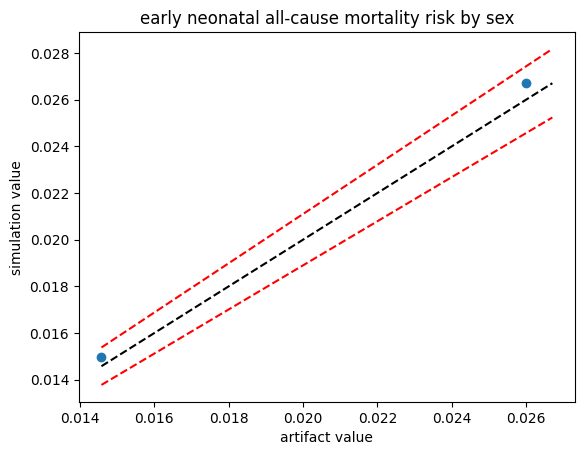

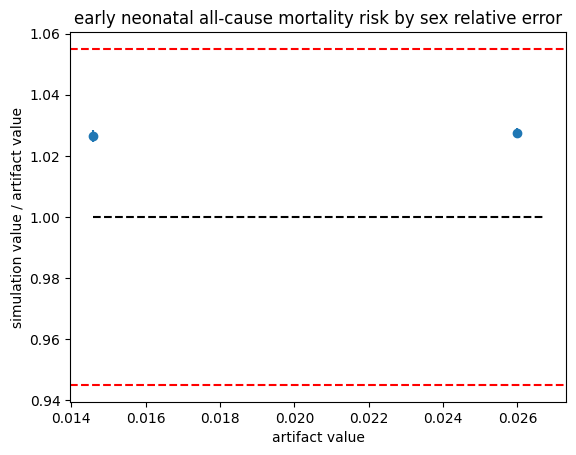

In [39]:
fuzzy_check(
    mortality_risk,
    enn_acmrisk_targets,
    "early neonatal all-cause mortality risk",
    acceptable_deviation=(
        DEVIATION_DUE_TO_IFA_LBWSG_MISCALIBRATION +
        (DEVIATION_DUE_TO_IFA_PRETERM_MISCALIBRATION * 0.5) # only through modification of preterm causes
    ),
)

#### Check individual steps in calculation of all-cause mortality risk

In [40]:
def step_by_step_check_acmrisk(age_group_start, age_group_end):
    acmrisk_targets = get_acmrisk_targets(age_group_start, age_group_end)
    # https://github.com/ihmeuw/vivarium_gates_mncnh/blob/86f8e36e8f781549cd6671cba9ad33912638dc4a/src/vivarium_gates_mncnh/components/mortality.py#L357-L361
    print('Initial mortality risk')
    initial_all_cause_mortality_risk = main_sim_components['neonatal_mortality'].all_cause_mortality_risk(alive_idx)
    # Does not vary except by sex
    assert (initial_all_cause_mortality_risk.groupby(pop.sex_of_child).nunique() == 1).all()
    # Exactly matches artifact values
    assert np.allclose(initial_all_cause_mortality_risk.groupby(pop.sex_of_child).mean(), acmrisk_targets, rtol=0, atol=1e-14)
    display(initial_all_cause_mortality_risk.groupby(pop.sex_of_child).mean())

    # Next (conceptually) is applying LBWSG PAF and RR
    lbwsg_effect_component = main_sim_components['risk_effect.low_birth_weight_and_short_gestation_on_cause.all_causes.all_cause_mortality_risk']
    lbwsg_paf = lbwsg_effect_component.paf_table(alive_idx)
    if age_group_start == 0 and age_group_end == LATE_NEONATAL_AGE_START:
        age_group_name = 'early_neonatal'
    elif age_group_start == LATE_NEONATAL_AGE_START and age_group_end == LATE_NEONATAL_AGE_END:
        age_group_name = 'late_neonatal'
    else:
        raise ValueError("Unknown age group")
    
    # https://github.com/ihmeuw/vivarium_gates_mncnh/blob/c82927dc163342720a53c95b1ee623a3305c9a49/src/vivarium_gates_mncnh/components/lbwsg.py#L490-L515
    pop_for_lbwsg_rr = main_sim.get_population(
        ['sex_of_child', 'gestational_age.exposure', 'birth_weight.exposure'],
    )

    is_male = pop_for_lbwsg_rr['sex_of_child'] == "Male"

    def get_relative_risk_for_age_group(pop: pd.DataFrame, age_group: str) -> pd.Series:
        birth_weight = pop['birth_weight']
        gestational_age = pop['gestational_age']

        is_tmrel = (lbwsg_effect_component.TMREL_GESTATIONAL_AGE_INTERVAL.left <= gestational_age) & (
            lbwsg_effect_component.TMREL_BIRTH_WEIGHT_INTERVAL.left <= birth_weight
        )

        column_name = lbwsg_effect_component.get_relative_risk_column_name(age_group)
        log_relative_risk = pd.Series(0.0, index=pop.index, name=column_name)

        male_interpolator = lbwsg_effect_component.interpolator["Male", age_group]
        log_relative_risk[is_male & ~is_tmrel] = male_interpolator(
            gestational_age[is_male & ~is_tmrel],
            birth_weight[is_male & ~is_tmrel],
            grid=False,
        )
        female_interpolator = lbwsg_effect_component.interpolator["Female", age_group]
        log_relative_risk[~is_male & ~is_tmrel] = female_interpolator(
            gestational_age[~is_male & ~is_tmrel],
            birth_weight[~is_male & ~is_tmrel],
            grid=False,
        )

        return np.exp(log_relative_risk)

    lbwsg_rr = get_relative_risk_for_age_group(pop_for_lbwsg_rr.rename(columns={'birth_weight.exposure': 'birth_weight', 'gestational_age.exposure': 'gestational_age'}), age_group_name).loc[alive_idx]
    assert lbwsg_rr.equals(pop.loc[alive_idx][f'effect_of_low_birth_weight_and_short_gestation_on_{age_group_name}_all_causes_relative_risk'])

    # Break down the steps of LBWSG
    lbwsg_pipeline = main_sim._population._attribute_pipelines['low_birth_weight_and_short_gestation.birth_exposure']
    assert lbwsg_pipeline(alive_idx)['gestational_age'].equals(pop_for_lbwsg_rr.loc[alive_idx, 'gestational_age.exposure'])
    assert lbwsg_pipeline(alive_idx)['birth_weight'].equals(pop_for_lbwsg_rr.loc[alive_idx, 'birth_weight.exposure'])

    working_lbwsg = lbwsg_pipeline.source(main_sim._population, alive_idx)

    def apply_lbwsg_effect(lbwsg_exposure):
        lbwsg_rr = get_relative_risk_for_age_group(lbwsg_exposure, age_group_name).loc[alive_idx]
        return initial_all_cause_mortality_risk * (1 - lbwsg_paf) * lbwsg_rr

    fuzzy_check(apply_lbwsg_effect(working_lbwsg), acmrisk_targets, "ACMRisk after LBWSG (using initial LBWSG)")

    acceptable_deviation = 0.0

    print('LBWSG mutators:')
    for mutator in lbwsg_pipeline.mutators:
        working_lbwsg = mutator(alive_idx, working_lbwsg.copy())
        if 'oral_iron_intervention_on_risk_factor' in mutator.name or 'iron_folic_acid_supplementation_on_risk_factor' in mutator.name:
            acceptable_deviation += DEVIATION_DUE_TO_IFA_LBWSG_MISCALIBRATION

        fuzzy_check(
            apply_lbwsg_effect(working_lbwsg),
            acmrisk_targets,
            f"ACMRisk after LBWSG (using LBWSG after {mutator.name})",
            acceptable_deviation=acceptable_deviation,
        )

    assert working_lbwsg['gestational_age'].equals(pop_for_lbwsg_rr.loc[alive_idx, 'gestational_age.exposure'])
    assert working_lbwsg['birth_weight'].equals(pop_for_lbwsg_rr.loc[alive_idx, 'birth_weight.exposure'])

    acmrisk_after_lbwsg = apply_lbwsg_effect(working_lbwsg)
    print('After LBWSG:')
    display(acmrisk_after_lbwsg.groupby(pop.sex_of_child).describe())

    fuzzy_check(
        acmrisk_after_lbwsg,
        acmrisk_targets,
        "ACMRisk after LBWSG",
        acceptable_deviation=acceptable_deviation,
    )

    # Check that we've exactly replicated everything up to mutators
    pop_mgr = main_sim._builder.population._manager
    pipeline = pop_mgr._get_attribute_pipelines()["death_in_age_group_probability"]
    assert np.allclose(acmrisk_after_lbwsg, pipeline.source(pop_mgr, alive_idx), rtol=0, atol=1e-14)

    # Now we add in CSMRisk-based modifications
    print('Mutators:')
    display([m.name for m in pipeline.mutators])

    working_acmrisk = acmrisk_after_lbwsg

    for mutator in pipeline.mutators:
        print(f'After {mutator.name}')
        working_acmrisk = mutator(alive_idx, working_acmrisk)

        if 'preterm' in mutator.name:
            acceptable_deviation += DEVIATION_DUE_TO_IFA_PRETERM_MISCALIBRATION * 0.5
        if 'preterm_with_rds' in mutator.name and age_group_name == 'late_neonatal':
            acceptable_deviation += DEVIATION_DUE_TO_LNN_CPAP_PAF_NOT_BEING_AGE_SPECIFIC * 0.5

        fuzzy_check(working_acmrisk, acmrisk_targets, "ACMRisk after mutator", acceptable_deviation=acceptable_deviation)

    # Check that we've exactly replicated everything
    assert np.allclose(working_acmrisk, pipeline(alive_idx), rtol=0, atol=1e-14)

Initial mortality risk


sex_of_child
Female    0.014576
Male      0.025991
Name: value, dtype: float64

Targets


sex
Female    0.014576
Male      0.025991
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.014574,0.047337,0.002568,0.002568,0.002984,0.005501,0.787830
Male,2820853.0,0.025979,0.068803,0.003957,0.003965,0.005159,0.011589,0.841283


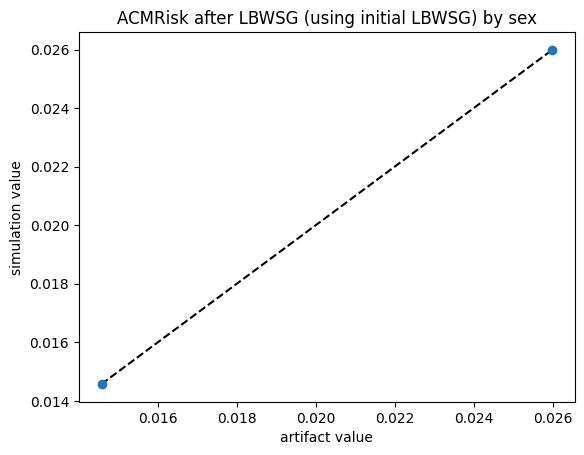

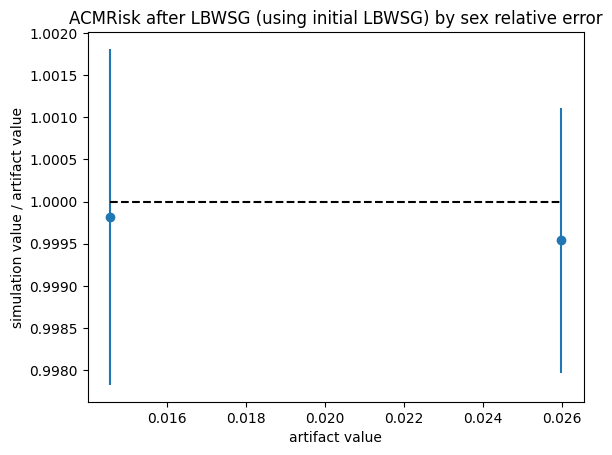

LBWSG mutators:


Targets


sex
Female    0.014576
Male      0.025991
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.014917,0.048061,0.002568,0.002568,0.003030,0.005781,0.787830
Male,2820853.0,0.026630,0.070013,0.003957,0.003969,0.005238,0.012200,0.841283


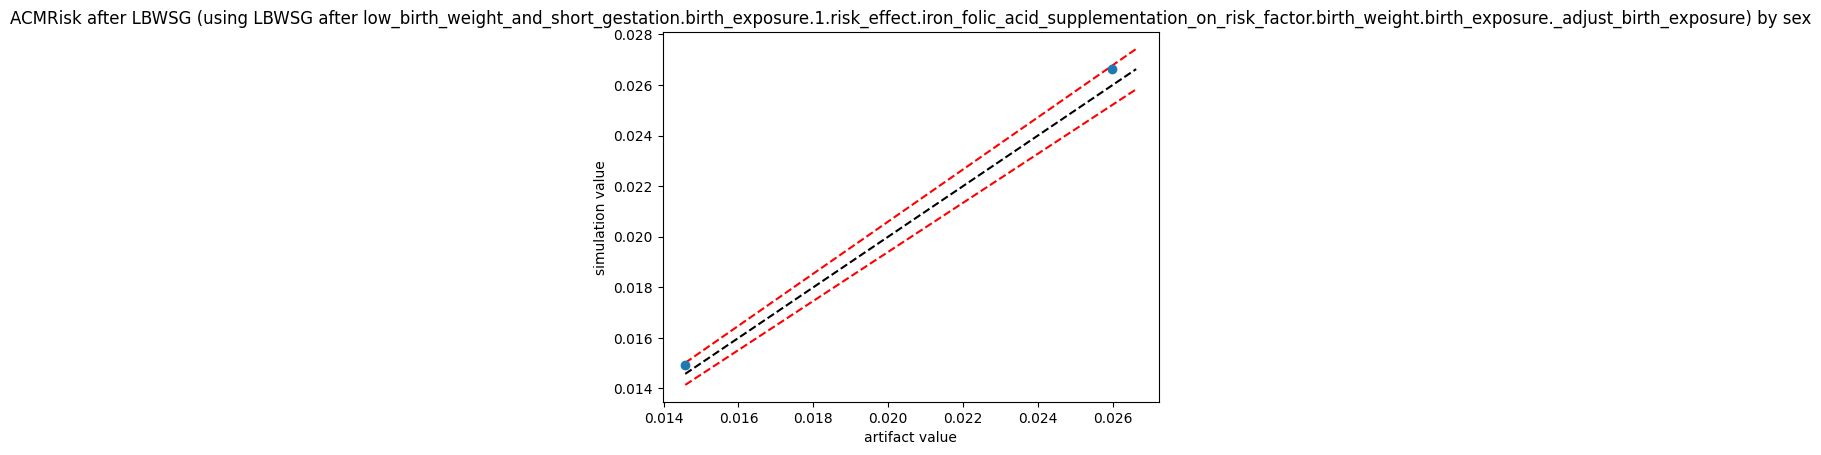

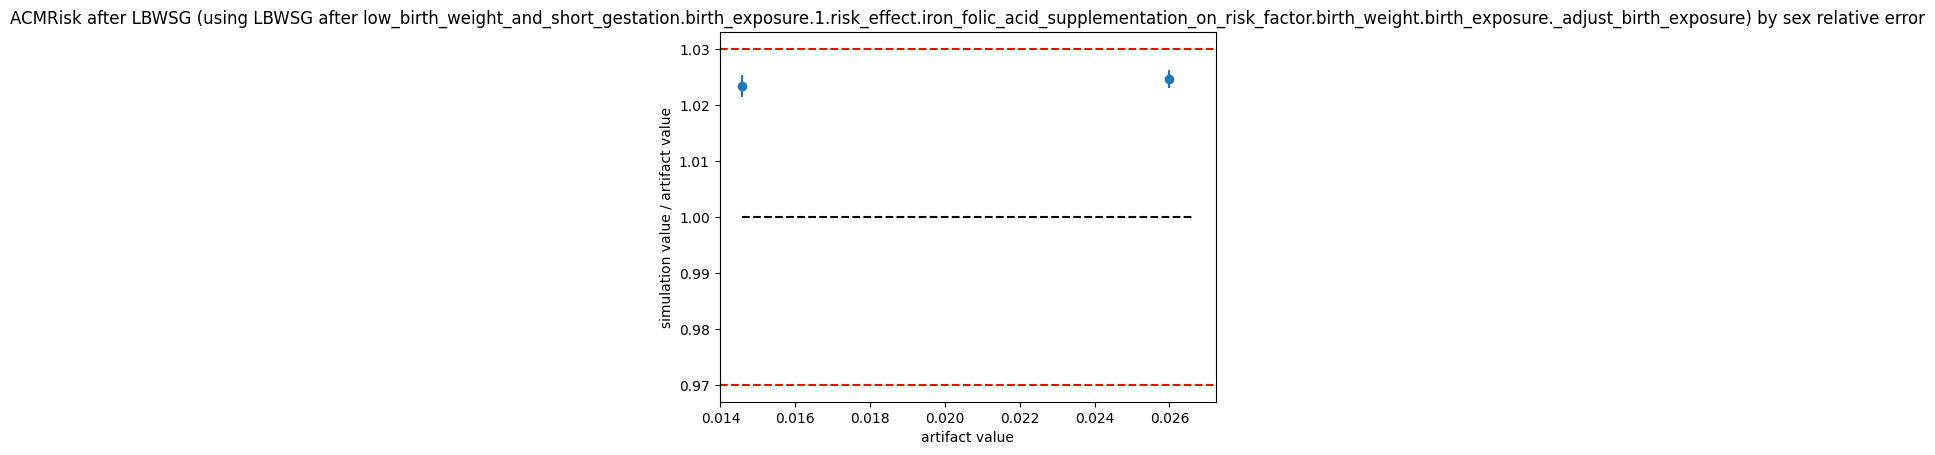

Targets


sex
Female    0.014576
Male      0.025991
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.014917,0.048061,0.002568,0.002568,0.003030,0.005781,0.787830
Male,2820853.0,0.026630,0.070013,0.003957,0.003969,0.005238,0.012200,0.841283


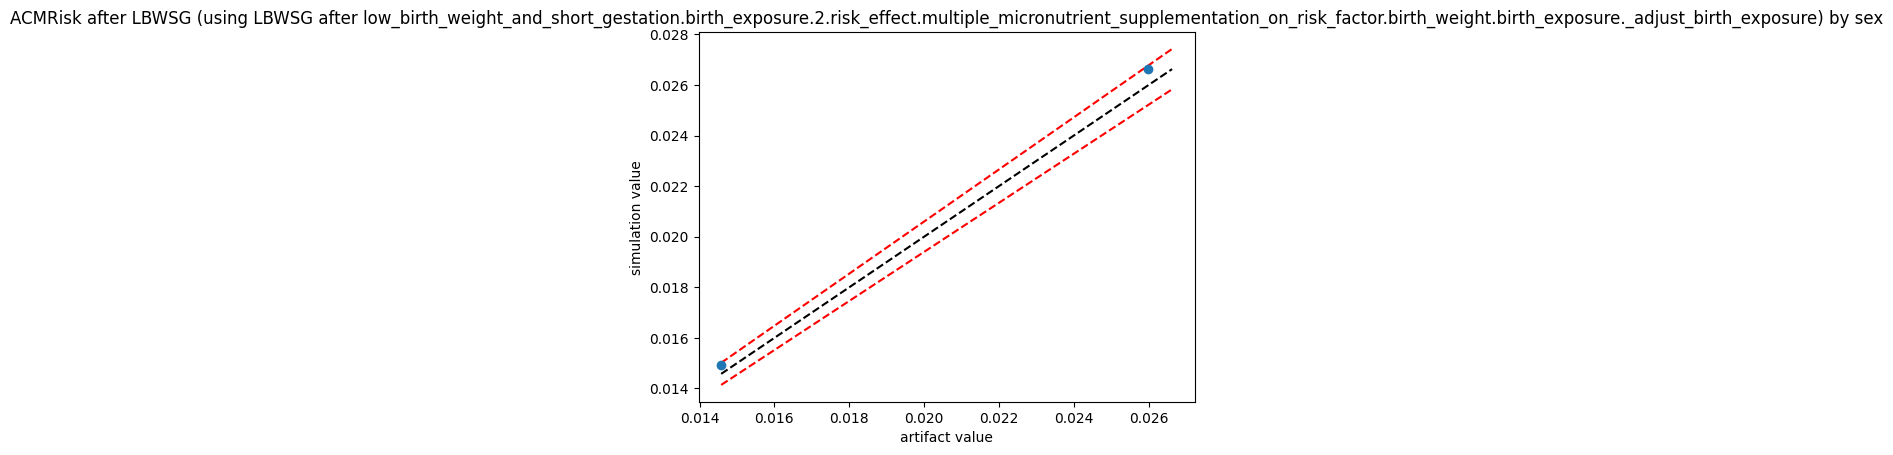

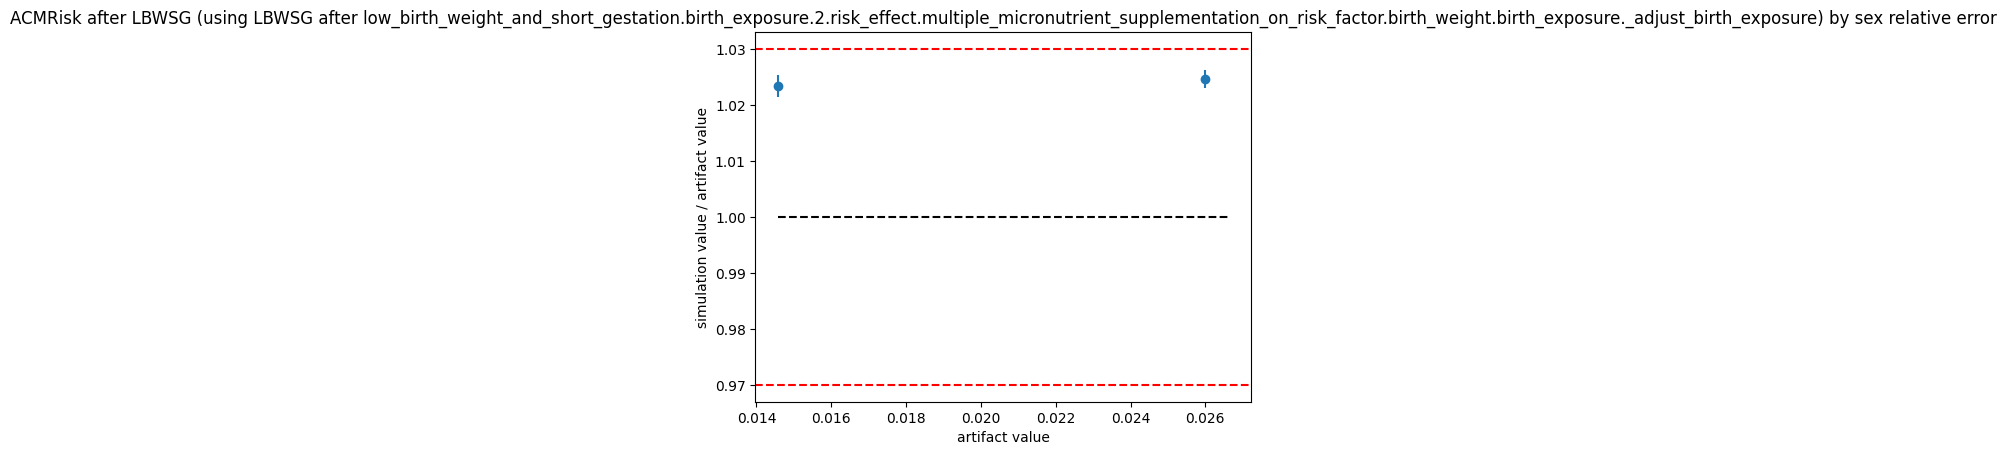

Targets


sex
Female    0.014576
Male      0.025991
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.014937,0.048117,0.002568,0.002568,0.003031,0.005788,0.787830
Male,2820853.0,0.026660,0.070060,0.003957,0.003970,0.005238,0.012225,0.841283


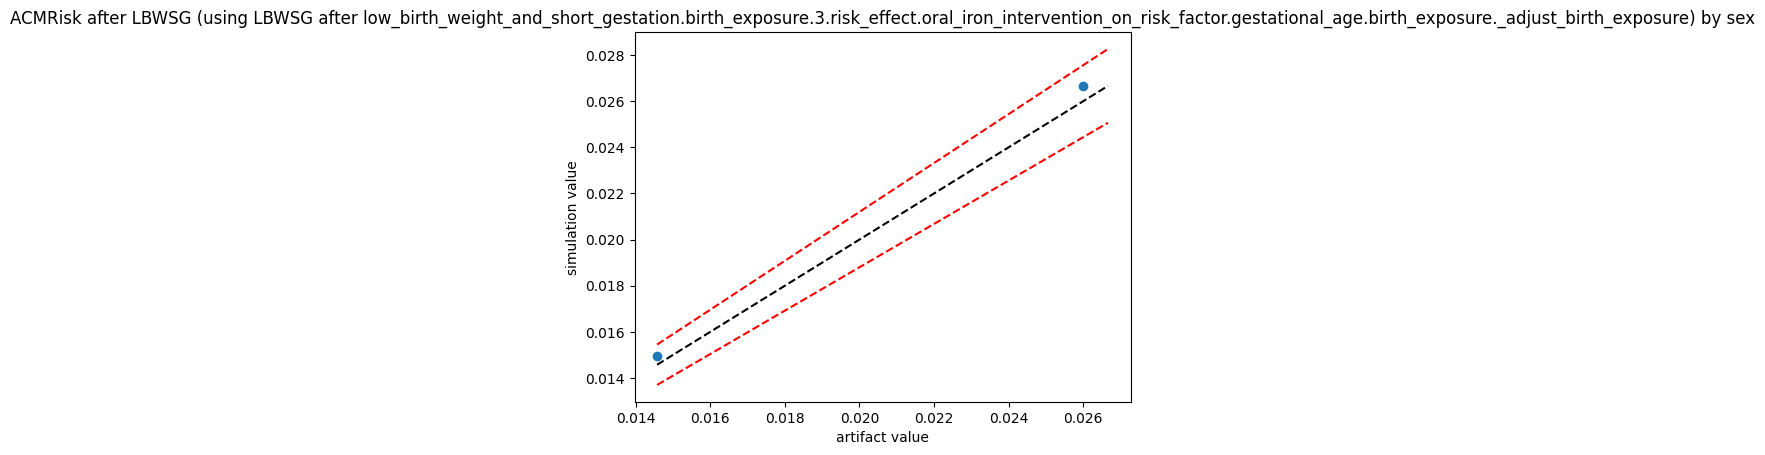

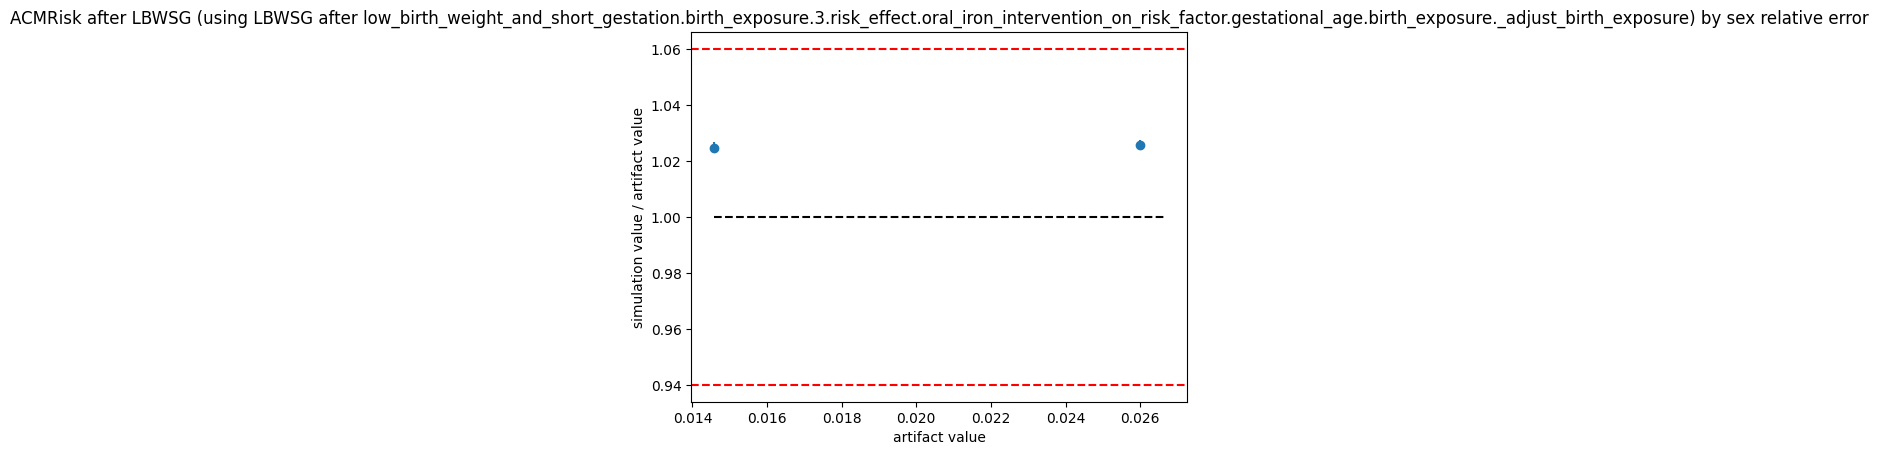

Targets


sex
Female    0.014576
Male      0.025991
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.014937,0.048117,0.002568,0.002568,0.003031,0.005788,0.787830
Male,2820853.0,0.026660,0.070060,0.003957,0.003970,0.005238,0.012225,0.841283


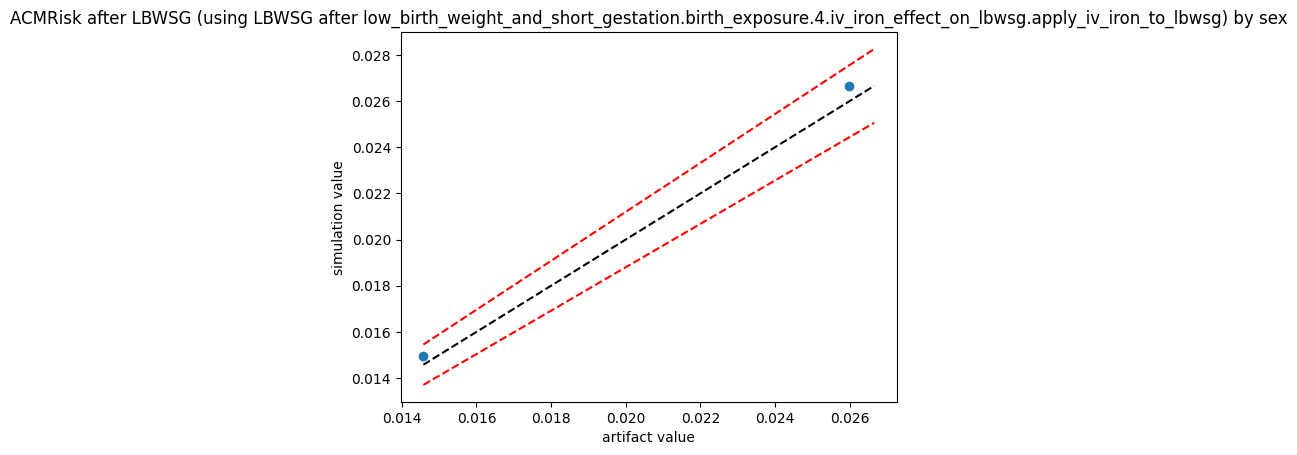

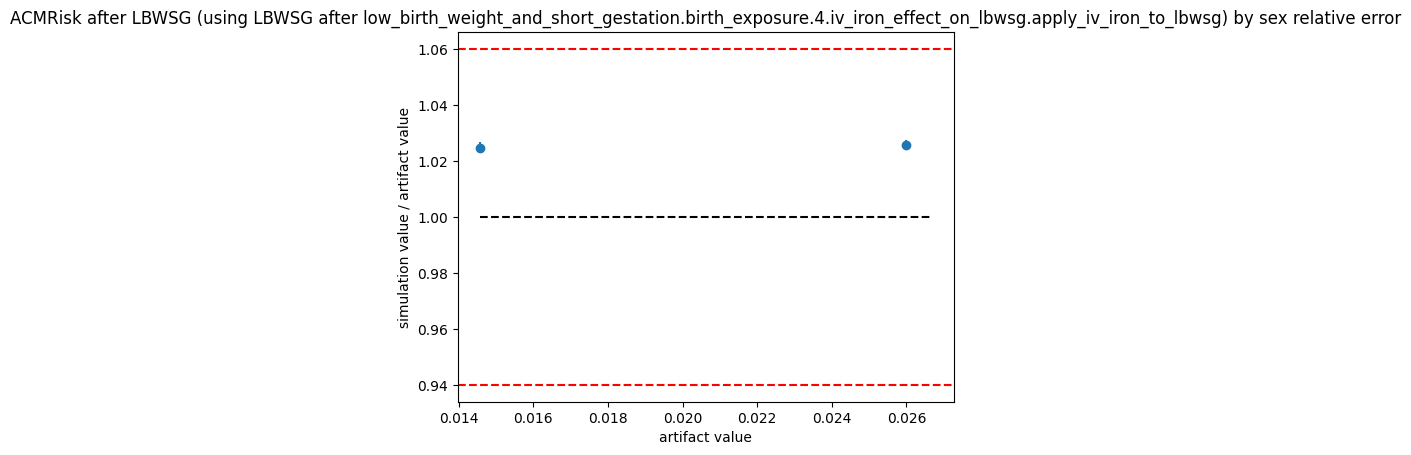

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.014937,0.048117,0.002568,0.002568,0.003031,0.005788,0.787830
Male,2820853.0,0.026660,0.070060,0.003957,0.003970,0.005238,0.012225,0.841283


Targets


sex
Female    0.014576
Male      0.025991
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.014937,0.048117,0.002568,0.002568,0.003031,0.005788,0.787830
Male,2820853.0,0.026660,0.070060,0.003957,0.003970,0.005238,0.012225,0.841283


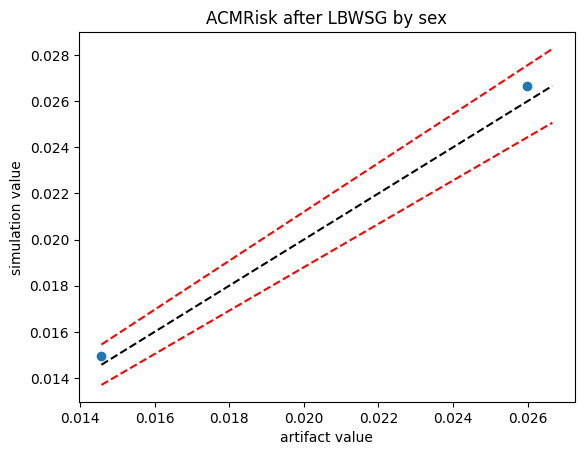

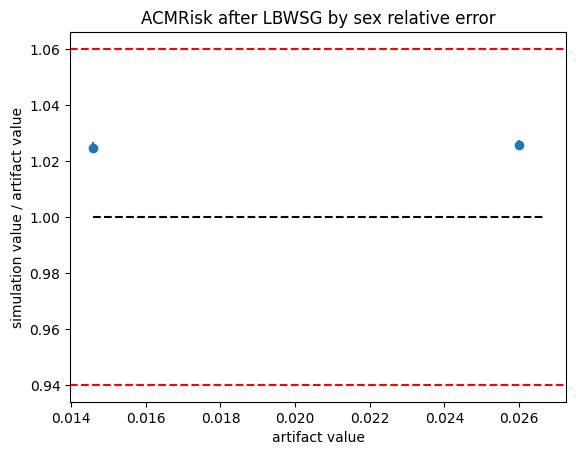

Mutators:


['death_in_age_group_probability.1.preterm_birth.neonatal_preterm_birth_with_rds.modify_death_in_age_group_probability',
 'death_in_age_group_probability.2.preterm_birth.neonatal_preterm_birth_without_rds.modify_death_in_age_group_probability',
 'death_in_age_group_probability.3.neonatal_cause.neonatal_sepsis_and_other_neonatal_infections.modify_death_in_age_group_probability',
 'death_in_age_group_probability.4.neonatal_cause.neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.modify_death_in_age_group_probability']

After death_in_age_group_probability.1.preterm_birth.neonatal_preterm_birth_with_rds.modify_death_in_age_group_probability


Targets


sex
Female    0.014576
Male      0.025991
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.014962,0.048505,0.002568,0.002568,0.003031,0.005784,0.821535
Male,2820853.0,0.026703,0.070724,0.003957,0.003970,0.005228,0.012202,0.884269


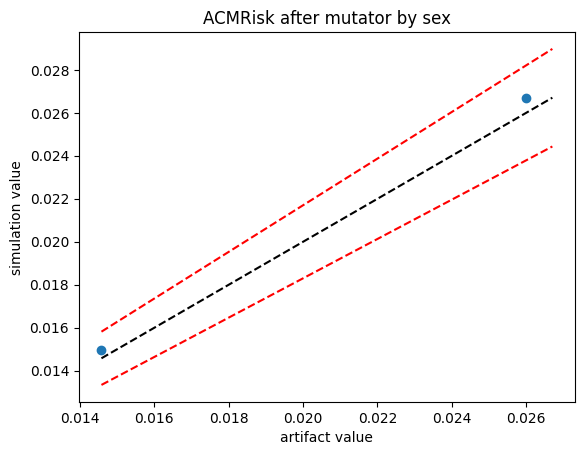

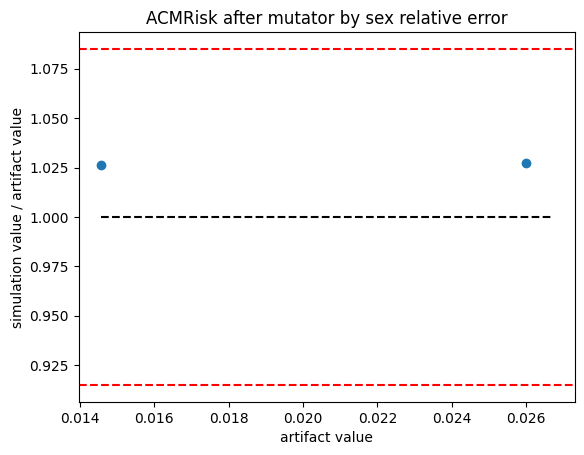

After death_in_age_group_probability.2.preterm_birth.neonatal_preterm_birth_without_rds.modify_death_in_age_group_probability


Targets


sex
Female    0.014576
Male      0.025991
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.014962,0.048505,0.002568,0.002568,0.003031,0.005784,0.821535
Male,2820853.0,0.026703,0.070724,0.003957,0.003970,0.005228,0.012202,0.884269


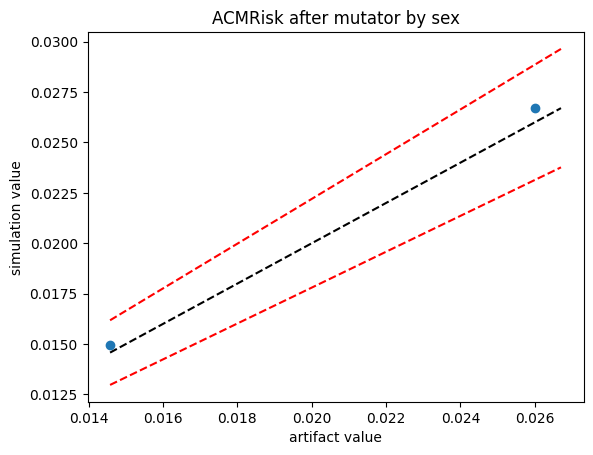

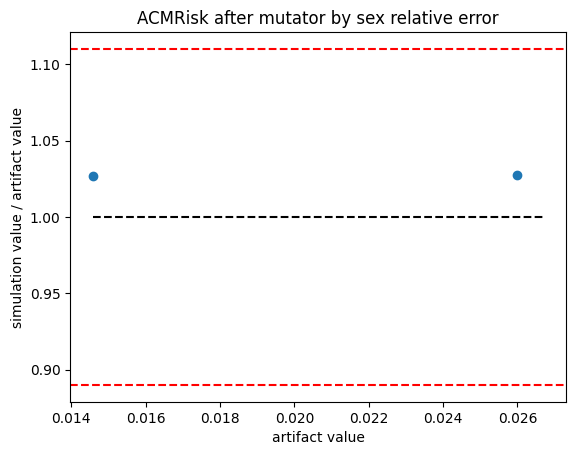

After death_in_age_group_probability.3.neonatal_cause.neonatal_sepsis_and_other_neonatal_infections.modify_death_in_age_group_probability


Targets


sex
Female    0.014576
Male      0.025991
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.014962,0.048506,0.002560,0.002576,0.003031,0.005783,0.823974
Male,2820853.0,0.026702,0.070722,0.003936,0.003978,0.005228,0.012202,0.888761


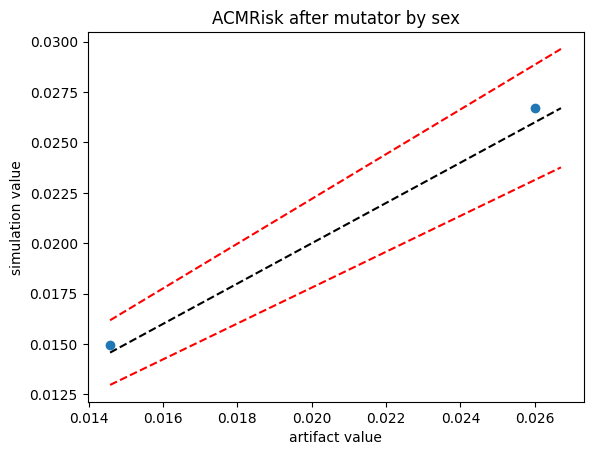

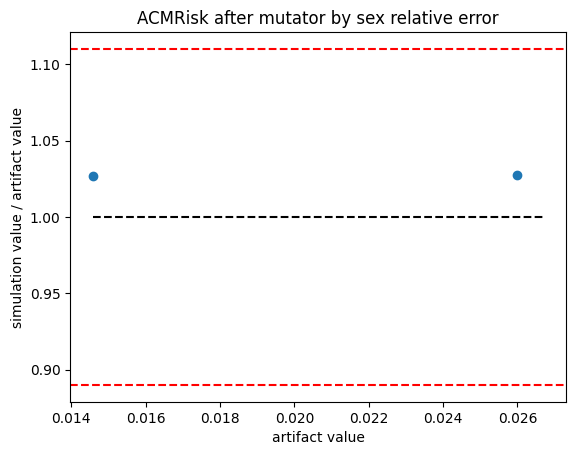

After death_in_age_group_probability.4.neonatal_cause.neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.modify_death_in_age_group_probability


Targets


sex
Female    0.014576
Male      0.025991
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.014962,0.048506,0.002560,0.002576,0.003031,0.005783,0.823974
Male,2820853.0,0.026702,0.070722,0.003936,0.003978,0.005228,0.012202,0.888761


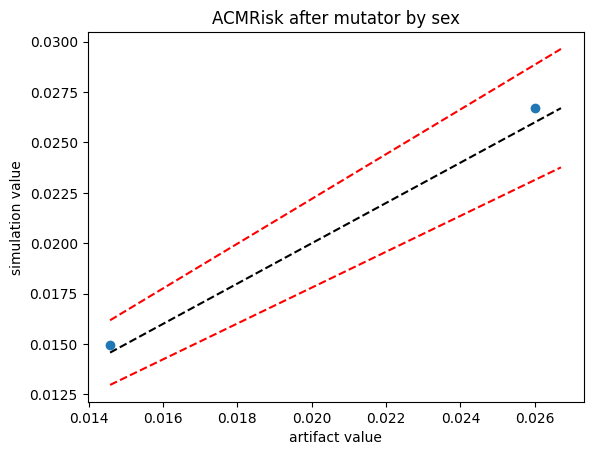

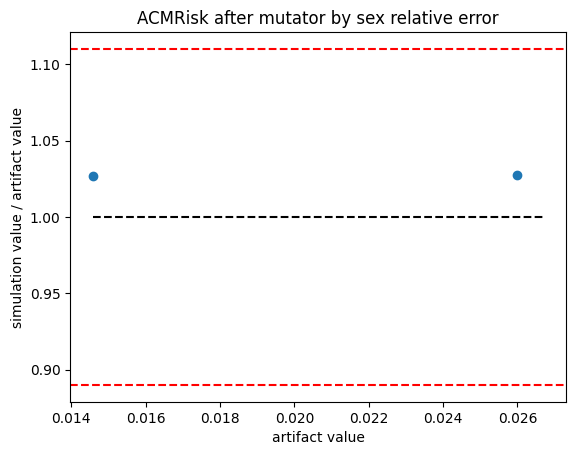

In [41]:
step_by_step_check_acmrisk(0, LATE_NEONATAL_AGE_START)

### Check cause-specific mortality risks

In [42]:
def get_csmrisk_targets(artifact_cause_name, age_group_start, age_group_end):
    return (
        art.load(f'cause.{artifact_cause_name}.mortality_risk')[f'draw_{draw_num}'].reset_index()
        .pipe(lambda df: df[(df.child_age_start == age_group_start) & (df.child_age_end == age_group_end)])
        .drop(columns=['child_age_start', 'child_age_end', 'year_start', 'year_end'])
        .set_index('sex_of_child')
        [f'draw_{draw_num}']
    )

neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma


Targets


sex_of_child
Female    0.004124
Male      0.009226
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.004226,0.013613,0.000727,0.000727,0.000858,0.001637,0.222881
Male,2820853.0,0.009464,0.024870,0.001405,0.001409,0.001859,0.004340,0.298638


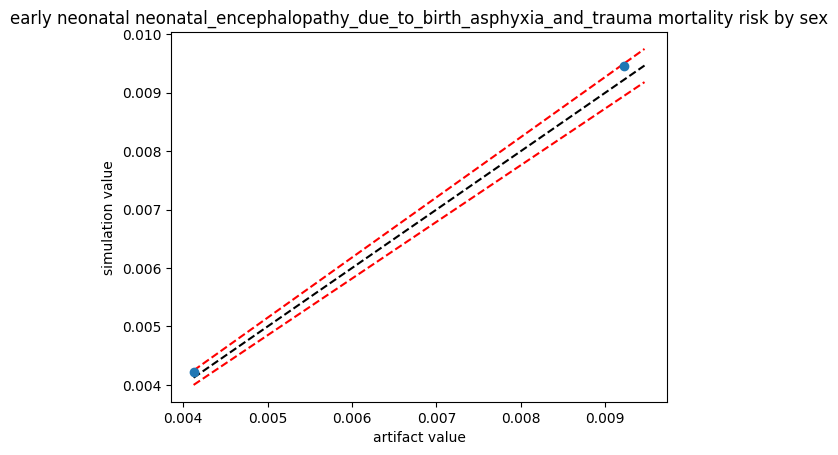

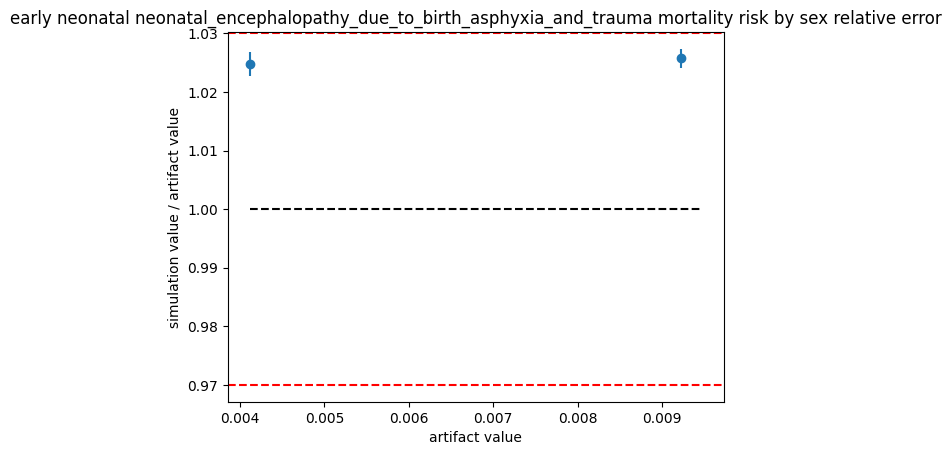

neonatal_sepsis_and_other_neonatal_infections


Targets


sex_of_child
Female    0.000861
Male      0.002649
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.000883,0.002848,0.000144,0.000160,0.000180,0.000342,0.048990
Male,2820853.0,0.002716,0.007148,0.000382,0.000424,0.000534,0.001251,0.090224


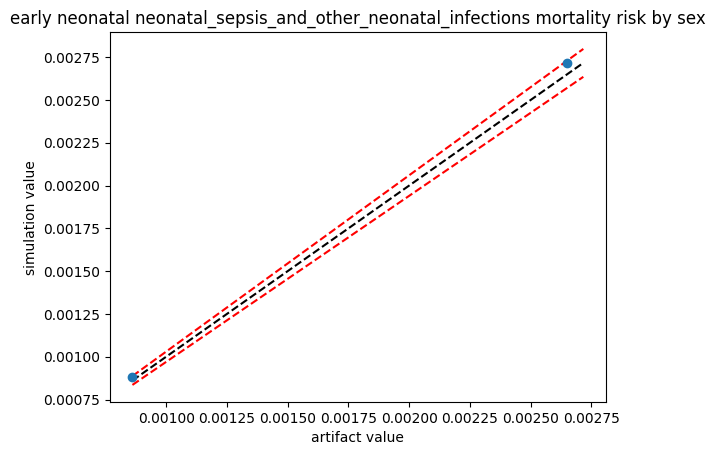

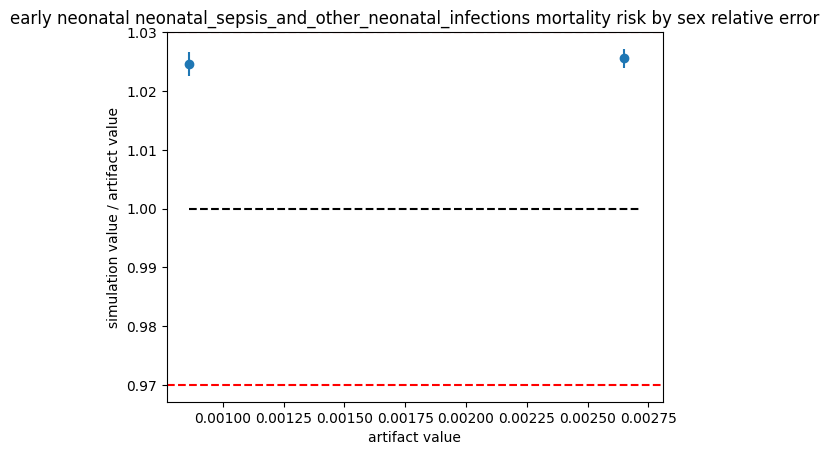

neonatal_preterm_birth


Targets


sex_of_child
Female    0.003228
Male      0.007147
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.003333,0.017942,0.0,0.0,0.0,0.0,0.336583
Male,2820853.0,0.007380,0.029889,0.0,0.0,0.0,0.0,0.429258


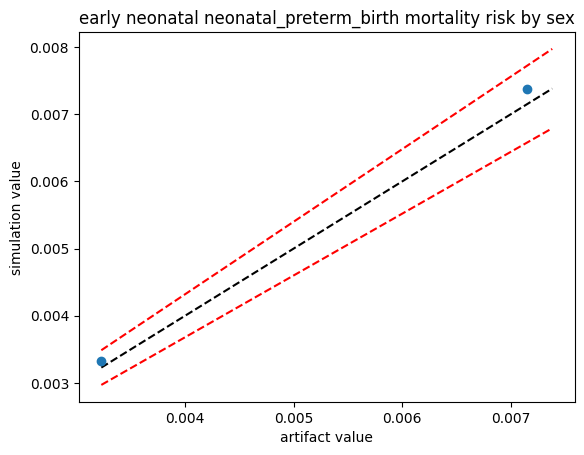

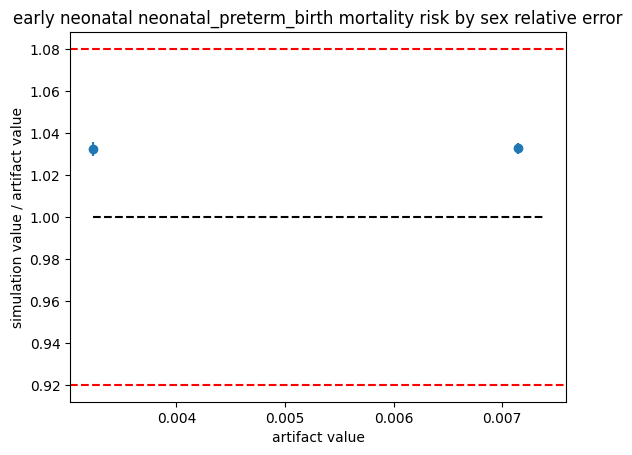

neonatal_preterm_birth_with_rds


Targets


sex_of_child
Female    0.002744
Male      0.006075
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.002837,0.015421,0.0,0.0,0.0,0.0,0.291151
Male,2820853.0,0.006280,0.025699,0.0,0.0,0.0,0.0,0.371317


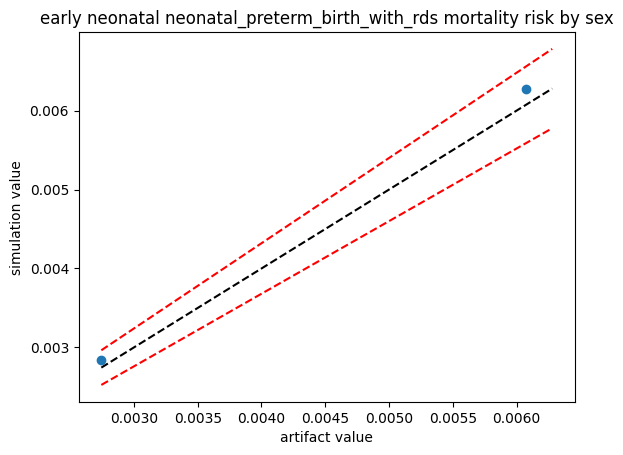

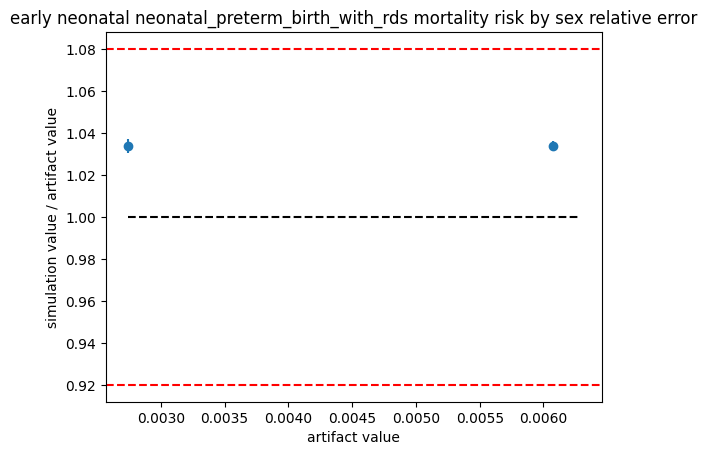

neonatal_preterm_birth_without_rds


Targets


sex_of_child
Female    0.000484
Male      0.001072
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.000496,0.002591,0.0,0.0,0.0,0.0,0.045432
Male,2820853.0,0.001101,0.004312,0.0,0.0,0.0,0.0,0.057941


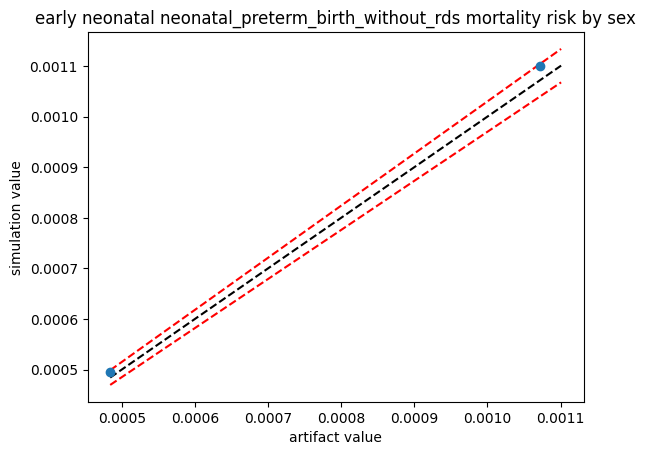

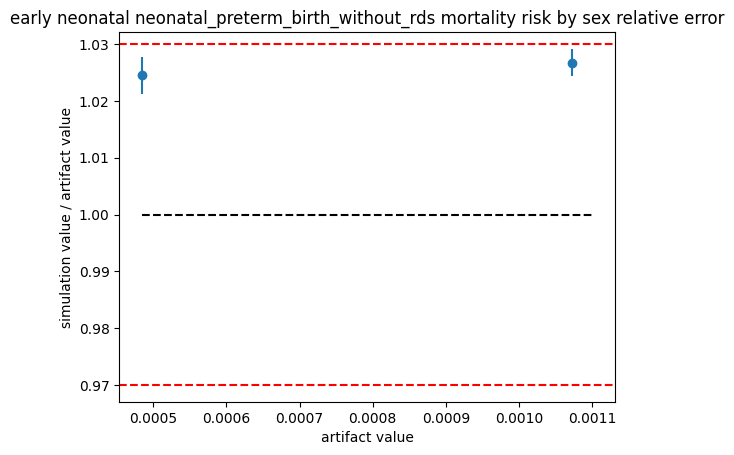

In [43]:
from vivarium_gates_mncnh.constants.data_values import PRETERM_DEATHS_DUE_TO_RDS_PROBABILITY

NEONATAL_CAUSES = [
    'neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma',
    'neonatal_sepsis_and_other_neonatal_infections',
    'neonatal_preterm_birth',
    'neonatal_preterm_birth_with_rds',
    'neonatal_preterm_birth_without_rds',
]

CAUSE_NAME_TO_CSMRISK_PIPELINES = {}
for cause_name in NEONATAL_CAUSES:
    if cause_name == 'neonatal_preterm_birth':
        CAUSE_NAME_TO_CSMRISK_PIPELINES[cause_name] = [
            "neonatal_preterm_birth_with_rds.csmr",
            "neonatal_preterm_birth_without_rds.csmr",
        ]
    else:
        CAUSE_NAME_TO_CSMRISK_PIPELINES[cause_name] = [f"{cause_name}.csmr"]

def check_csmrisks(age_group_start, age_group_end):
    for cause_name in NEONATAL_CAUSES:
        print(cause_name)

        pipeline_names = CAUSE_NAME_TO_CSMRISK_PIPELINES[cause_name]
        csmrisk_values = 0
        for pipeline_name in pipeline_names:
            csmrisk_values += (
                main_sim.get_population(pipeline_name).loc[alive_idx]
            )

        artifact_cause_name = cause_name.replace('_with_rds', '').replace('_without_rds', '')
        csmrisk_targets = get_csmrisk_targets(artifact_cause_name, age_group_start, age_group_end)

        if cause_name == 'neonatal_preterm_birth_with_rds':
            csmrisk_targets *= PRETERM_DEATHS_DUE_TO_RDS_PROBABILITY
        elif cause_name == 'neonatal_preterm_birth_without_rds':
            csmrisk_targets *= (1 - PRETERM_DEATHS_DUE_TO_RDS_PROBABILITY)

        acceptable_deviation = DEVIATION_DUE_TO_IFA_LBWSG_MISCALIBRATION

        if cause_name in ('neonatal_preterm_birth', 'neonatal_preterm_birth_with_rds'):
            acceptable_deviation += DEVIATION_DUE_TO_IFA_PRETERM_MISCALIBRATION
            if age_group_start == LATE_NEONATAL_AGE_START:
                acceptable_deviation += DEVIATION_DUE_TO_LNN_CPAP_PAF_NOT_BEING_AGE_SPECIFIC

        fuzzy_check(csmrisk_values, csmrisk_targets, f"early neonatal {cause_name} mortality risk", acceptable_deviation=acceptable_deviation)

check_csmrisks(0, LATE_NEONATAL_AGE_START)

#### Check frequency of negative other-causes mortality, and impact

This isn't the best check because it is only for a single draw and location. In the one I've chosen, this rarely happens, apparently.

In [44]:
csmrisk_pipeline_names = sorted({item for values in CAUSE_NAME_TO_CSMRISK_PIPELINES.values() for item in values})
csmrisk_pipeline_names

['neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.csmr',
 'neonatal_preterm_birth_with_rds.csmr',
 'neonatal_preterm_birth_without_rds.csmr',
 'neonatal_sepsis_and_other_neonatal_infections.csmr']

In [45]:
total_csmrisk = 0

for pipeline_name in csmrisk_pipeline_names:
    total_csmrisk += (
        main_sim.get_population(pipeline_name).loc[alive_idx]
    )

total_csmrisk

1          0.001787
3          0.002112
4          0.002088
5          0.066591
6          0.049111
             ...   
9999990    0.001105
9999995    0.001858
9999996    0.000886
9999997    0.139639
9999998    0.001067
Name: neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.csmr, Length: 5475223, dtype: float64

In [46]:
total_csmrisk.describe()

count    5.475223e+06
mean     1.417010e-02
std      4.881433e-02
min      8.703052e-04
25%      1.056876e-03
50%      1.843996e-03
75%      4.499850e-03
max      8.181196e-01
Name: neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.csmr, dtype: float64

In [47]:
(total_csmrisk > mortality_risk).mean()

0.0

In [48]:
# Expect CSMRisks to be underestimated by this amount as a result
(total_csmrisk - mortality_risk).clip(0).sum() / total_csmrisk.sum()

0.0

#### Check individual steps in calculation of cause-specific mortality risks

In [49]:
def step_by_step_check_csmrisk(cause_name, age_group_start, age_group_end):
    artifact_cause_name = cause_name.replace('_with_rds', '').replace('_without_rds', '')
    csmrisk_targets = get_csmrisk_targets(artifact_cause_name, age_group_start, age_group_end)

    # https://github.com/ihmeuw/vivarium_gates_mncnh/blob/86f8e36e8f781549cd6671cba9ad33912638dc4a/src/vivarium_gates_mncnh/components/mortality.py#L357-L361
    print('Initial cause-specific mortality risk')
    component_name = ('preterm_birth.' if 'preterm_birth' in cause_name else 'neonatal_cause.') + cause_name
    component = main_sim_components[component_name]
    initial_csmrisk = component.csmrisk_table(alive_idx)
    # Does not vary except by sex
    assert (initial_csmrisk.groupby(pop.sex_of_child).nunique() == 1).all()
    # Exactly matches artifact values
    assert np.allclose(initial_csmrisk.groupby(pop.sex_of_child).mean(), csmrisk_targets, rtol=0, atol=1e-14)
    display(initial_csmrisk.groupby(pop.sex_of_child).mean())

    # https://github.com/ihmeuw/vivarium_gates_mncnh/blob/7886d2bcb71fd2c3e497997a2bcf44c43569b8ab/src/vivarium_gates_mncnh/components/neonatal_causes.py#L116-L136
    global any_failures
    acceptable_deviation = 0.0
    if 'preterm_birth' in cause_name:
        # Next step (conceptually) is limiting to preterm babies
        print('Preterm prevalence target:')
        prevalence = component.prevalence_table(alive_idx)
        # Does not vary except by sex
        assert (prevalence.groupby(pop.sex_of_child).nunique() == 1).all()
        display(prevalence.groupby(pop.sex_of_child).mean())

        lbwsg_pipeline = main_sim._population._attribute_pipelines['low_birth_weight_and_short_gestation.birth_exposure']
        assert lbwsg_pipeline(alive_idx)['gestational_age'].equals(main_sim.get_population("gestational_age.exposure").loc[alive_idx])

        working_lbwsg = lbwsg_pipeline.source(main_sim._population, alive_idx)
        print('Initial preterm prevalence based on LBWSG pipeline source:')
        display((working_lbwsg['gestational_age'] < 37).groupby(pop.loc[alive_idx, 'sex_of_child']).mean())

        def limit_to_preterm(csmrisk, gestational_age):
            limited_csmrisk_preterm = csmrisk / prevalence
            limited_csmrisk_preterm.loc[gestational_age >= 37] = 0
            return limited_csmrisk_preterm

        fuzzy_check(limit_to_preterm(initial_csmrisk, working_lbwsg['gestational_age']), csmrisk_targets, "CSMRisk after limiting to preterm (using initial GA)")

        print('GA mutators:')
        for mutator in lbwsg_pipeline.mutators:
            after_mutator = mutator(alive_idx, working_lbwsg.copy())
            if not after_mutator['gestational_age'].equals(working_lbwsg['gestational_age']):
                print(f'After {mutator.name}, preterm prevalence:')
                display((after_mutator['gestational_age'] < 37).groupby(pop.loc[alive_idx, 'sex_of_child']).mean())

                if 'oral_iron_intervention_on_risk_factor.gestational_age' in mutator.name:
                    acceptable_deviation += DEVIATION_DUE_TO_IFA_PRETERM_MISCALIBRATION

                fuzzy_check(
                    limit_to_preterm(initial_csmrisk, after_mutator['gestational_age']),
                    csmrisk_targets,
                    f"CSMRisk after limiting to preterm (using GA after {mutator.name})",
                    acceptable_deviation=acceptable_deviation,
                )
            working_lbwsg = after_mutator

        assert working_lbwsg['gestational_age'].equals(main_sim.get_population("gestational_age.exposure").loc[alive_idx])
        for sex in ['Female', 'Male']:
            try:
                target_proportion = prevalence.loc[alive_idx].groupby(pop.loc[alive_idx].sex_of_child).mean()[sex]
                target_proportion = (target_proportion * (1 - acceptable_deviation), target_proportion * (1 + acceptable_deviation))
                fuzzy_checker.fuzzy_assert_proportion(
                    (working_lbwsg['gestational_age'] < 37)[pop.loc[alive_idx].sex_of_child == sex].sum(),
                    (pop.loc[alive_idx].sex_of_child == sex).sum(),
                    target_proportion
                )
            except AssertionError as e:
                print(e)
                any_failures = True
    
        limited_csmrisk_preterm = limit_to_preterm(initial_csmrisk, working_lbwsg['gestational_age'])
        display(limited_csmrisk_preterm.groupby(pop.sex_of_child).mean())

        working_csmrisk = limited_csmrisk_preterm

        if cause_name == 'neonatal_preterm_birth_with_rds':
            working_csmrisk = working_csmrisk * PRETERM_DEATHS_DUE_TO_RDS_PROBABILITY
            csmrisk_targets = csmrisk_targets * PRETERM_DEATHS_DUE_TO_RDS_PROBABILITY
        elif cause_name == 'neonatal_preterm_birth_without_rds':
            working_csmrisk = working_csmrisk * (1 - PRETERM_DEATHS_DUE_TO_RDS_PROBABILITY)
            csmrisk_targets = csmrisk_targets * (1 - PRETERM_DEATHS_DUE_TO_RDS_PROBABILITY)
        
        fuzzy_check(
            working_csmrisk,
            csmrisk_targets,
            "CSMRisk after splitting to subcause",
            acceptable_deviation=acceptable_deviation
        )
    else:
        working_csmrisk = initial_csmrisk

    if age_group_start == 0 and age_group_end == LATE_NEONATAL_AGE_START:
        age_group_name = 'early_neonatal'
    elif age_group_start == LATE_NEONATAL_AGE_START and age_group_end == LATE_NEONATAL_AGE_END:
        age_group_name = 'late_neonatal'
    else:
        raise ValueError("Unknown age group")

    # Next (conceptually) is applying LBWSG PAF/normalizing constant and RR
    # TODO: Why is this different! Note that there is a PAF table on the risk effect, but it is not actually used!
    if 'preterm_birth' in cause_name:
        lbwsg_paf = component.paf_table(alive_idx)
    else:
        lbwsg_paf = main_sim_components[f'risk_effect.low_birth_weight_and_short_gestation_on_cause.{cause_name}.cause_specific_mortality_risk'].paf_table(alive_idx)
    lbwsg_rr = main_sim.get_population(f'effect_of_low_birth_weight_and_short_gestation_on_{age_group_name}_{cause_name}_relative_risk').loc[alive_idx]

    csmrisk_after_lbwsg = working_csmrisk * (1 - lbwsg_paf) * lbwsg_rr
    print('After LBWSG:')
    display(csmrisk_after_lbwsg.groupby(pop.sex_of_child).describe())

    acceptable_deviation += DEVIATION_DUE_TO_IFA_LBWSG_MISCALIBRATION
    fuzzy_check(csmrisk_after_lbwsg, csmrisk_targets, "CSMRisk after LBWSG", acceptable_deviation=acceptable_deviation)

    pipeline_names = CAUSE_NAME_TO_CSMRISK_PIPELINES[cause_name]
    assert len(pipeline_names) == 1
    pop_mgr = main_sim._builder.population._manager
    pipeline = pop_mgr._get_attribute_pipelines()[pipeline_names[0]]

    # Check that we've exactly replicated everything up to mutators
    assert np.allclose(csmrisk_after_lbwsg, pipeline.source(pop_mgr, alive_idx), rtol=0, atol=1e-14)

    # Now we add in intervention-based modifications
    print('Mutators:')
    display([m.name for m in pipeline.mutators])

    working_csmrisk = csmrisk_after_lbwsg

    if age_group_name == 'late_neonatal' and cause_name in ('neonatal_preterm_birth', 'neonatal_preterm_birth_with_rds'):
        acceptable_deviation += DEVIATION_DUE_TO_LNN_CPAP_PAF_NOT_BEING_AGE_SPECIFIC

    for mutator in pipeline.mutators:
        print(f'After {mutator.name}')
        mutator_component = mutator._source.__self__
        if mutator_component.name.startswith('intervention_risk_effect'):
            intervention_coverage = main_sim.get_population(mutator_component.col_required).loc[alive_idx]
            print(f'{mutator_component.col_required} coverage: {intervention_coverage.mean():.2%}')

        working_csmrisk = mutator(alive_idx, working_csmrisk)
        fuzzy_check(working_csmrisk, csmrisk_targets, "CSMRisk after mutator", acceptable_deviation=acceptable_deviation)

    # Check that we've exactly replicated everything
    assert np.allclose(working_csmrisk, pipeline(alive_idx), rtol=0, atol=1e-14)

neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma
Initial cause-specific mortality risk


sex_of_child
Female    0.004124
Male      0.009226
Name: value, dtype: float64

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.004226,0.013613,0.000727,0.000727,0.000858,0.001637,0.222881
Male,2820853.0,0.009464,0.024870,0.001405,0.001409,0.001859,0.004340,0.298638


Targets


sex_of_child
Female    0.004124
Male      0.009226
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.004226,0.013613,0.000727,0.000727,0.000858,0.001637,0.222881
Male,2820853.0,0.009464,0.024870,0.001405,0.001409,0.001859,0.004340,0.298638


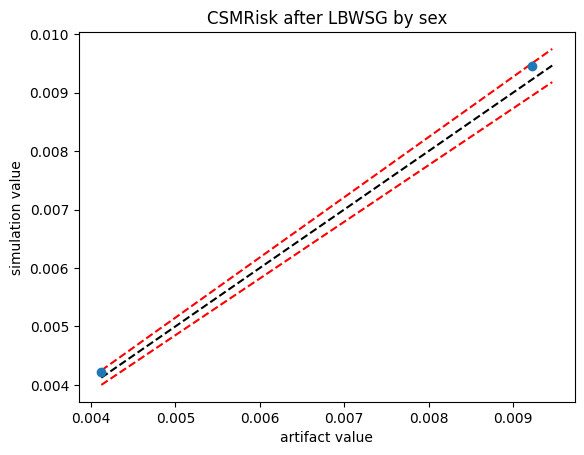

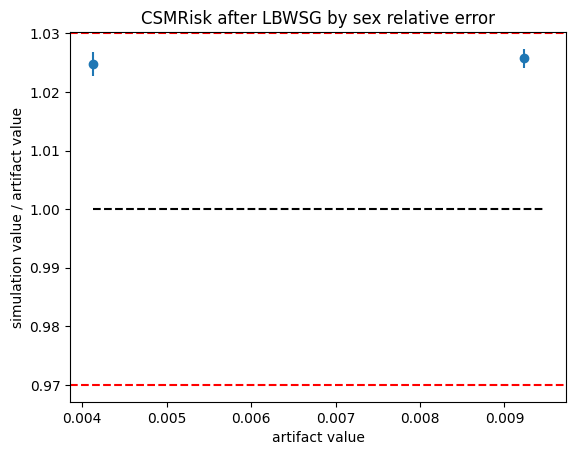

Mutators:


[]

neonatal_sepsis_and_other_neonatal_infections
Initial cause-specific mortality risk


sex_of_child
Female    0.000861
Male      0.002649
Name: value, dtype: float64

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.000883,0.002843,0.000152,0.000152,0.000179,0.000342,0.046551
Male,2820853.0,0.002717,0.007139,0.000403,0.000405,0.000534,0.001246,0.085732


Targets


sex_of_child
Female    0.000861
Male      0.002649
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.000883,0.002843,0.000152,0.000152,0.000179,0.000342,0.046551
Male,2820853.0,0.002717,0.007139,0.000403,0.000405,0.000534,0.001246,0.085732


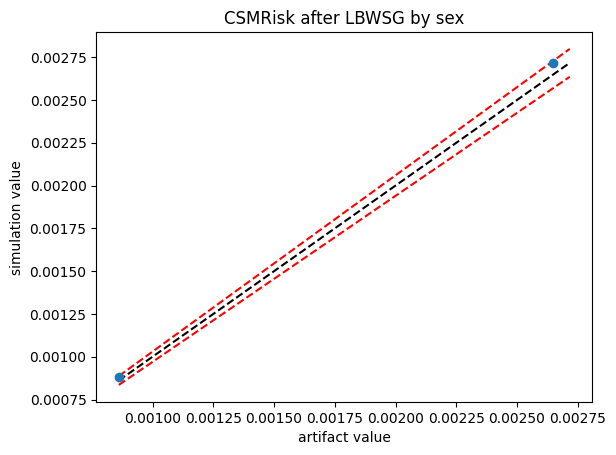

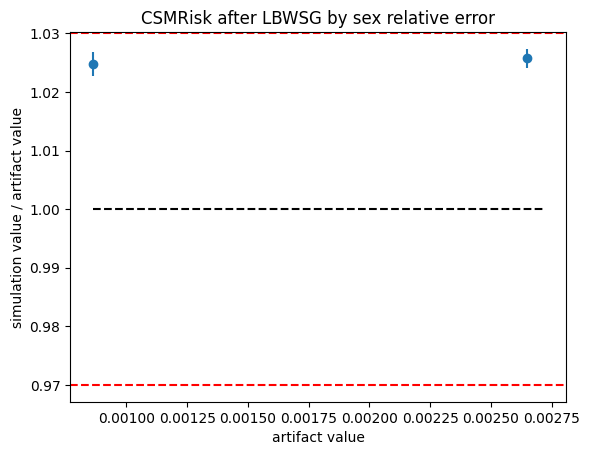

Mutators:


['neonatal_sepsis_and_other_neonatal_infections.csmr.1.intervention_risk_effect.antibiotics.modify_target_pipeline',
 'neonatal_sepsis_and_other_neonatal_infections.csmr.2.intervention_risk_effect.probiotics.modify_target_pipeline']

After neonatal_sepsis_and_other_neonatal_infections.csmr.1.intervention_risk_effect.antibiotics.modify_target_pipeline


antibiotics_available coverage: 50.03%


Targets


sex_of_child
Female    0.000861
Male      0.002649
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.000883,0.002848,0.000144,0.000160,0.000180,0.000342,0.048990
Male,2820853.0,0.002716,0.007148,0.000382,0.000424,0.000534,0.001251,0.090224


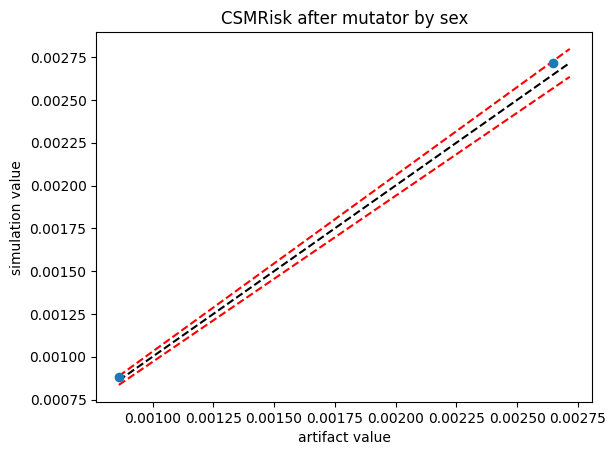

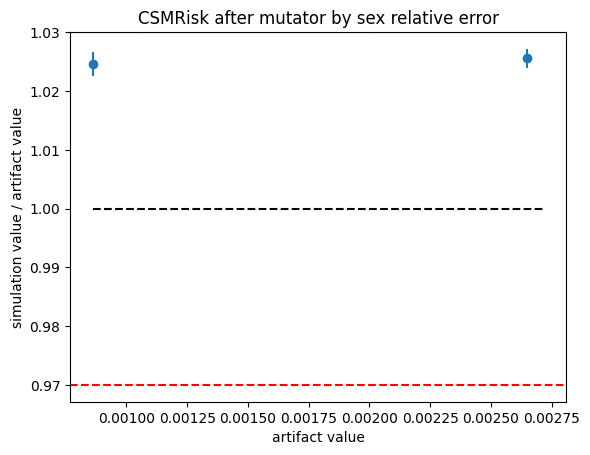

After neonatal_sepsis_and_other_neonatal_infections.csmr.2.intervention_risk_effect.probiotics.modify_target_pipeline


probiotics_available coverage: 0.00%


Targets


sex_of_child
Female    0.000861
Male      0.002649
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.000883,0.002848,0.000144,0.000160,0.000180,0.000342,0.048990
Male,2820853.0,0.002716,0.007148,0.000382,0.000424,0.000534,0.001251,0.090224


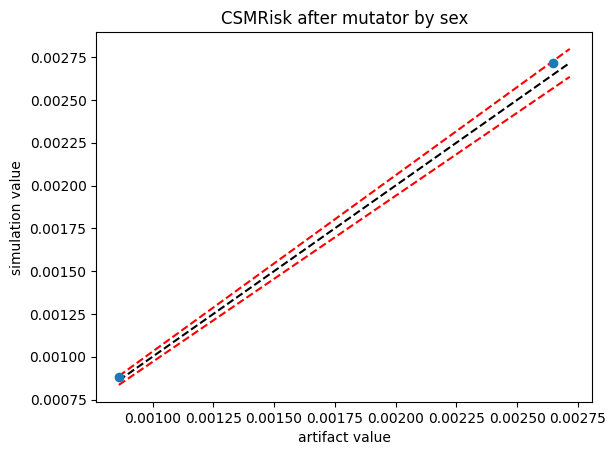

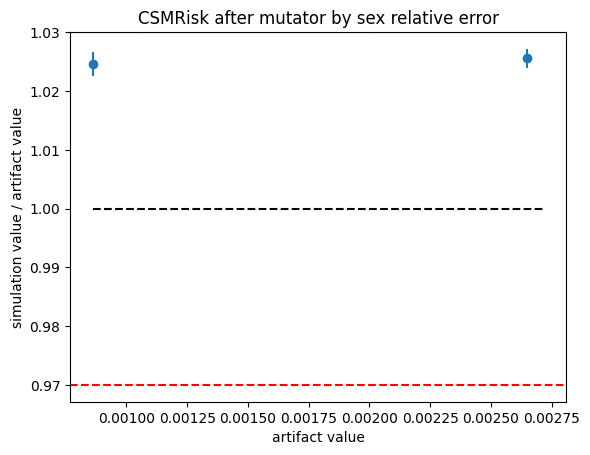

neonatal_preterm_birth_with_rds
Initial cause-specific mortality risk


sex_of_child
Female    0.003228
Male      0.007147
Name: value, dtype: float64

Preterm prevalence target:


sex_of_child
Female    0.139787
Male      0.190916
Name: value, dtype: float64

Initial preterm prevalence based on LBWSG pipeline source:


sex_of_child
Female    0.140179
Male      0.190752
Name: gestational_age, dtype: float64

Targets


sex_of_child
Female    0.003228
Male      0.007147
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.003237,0.008018,0.0,0.0,0.0,0.0,0.023095
Male,2820853.0,0.007141,0.014708,0.0,0.0,0.0,0.0,0.037435


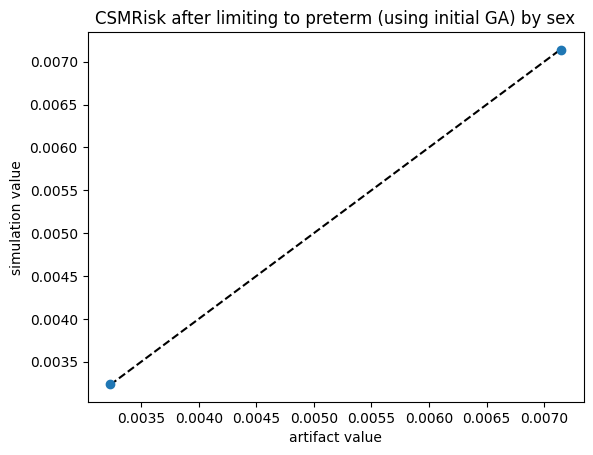

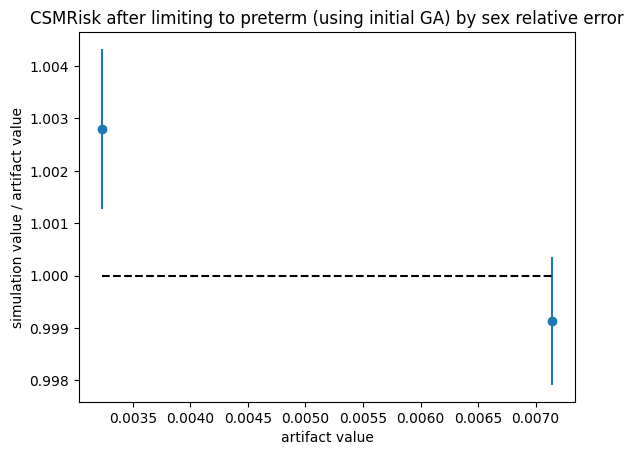

GA mutators:


After low_birth_weight_and_short_gestation.birth_exposure.3.risk_effect.oral_iron_intervention_on_risk_factor.gestational_age.birth_exposure._adjust_birth_exposure, preterm prevalence:


sex_of_child
Female    0.147373
Male      0.198782
Name: gestational_age, dtype: float64

Targets


sex_of_child
Female    0.003228
Male      0.007147
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.003404,0.008187,0.0,0.0,0.0,0.0,0.023095
Male,2820853.0,0.007441,0.014940,0.0,0.0,0.0,0.0,0.037435


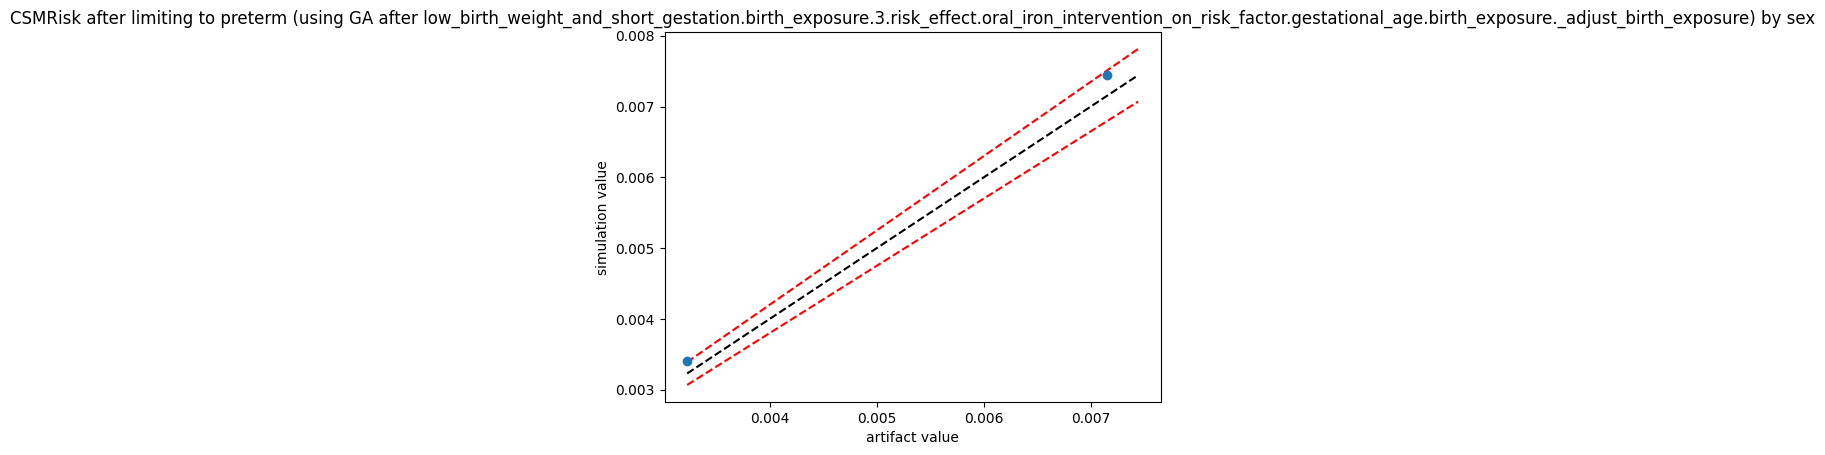

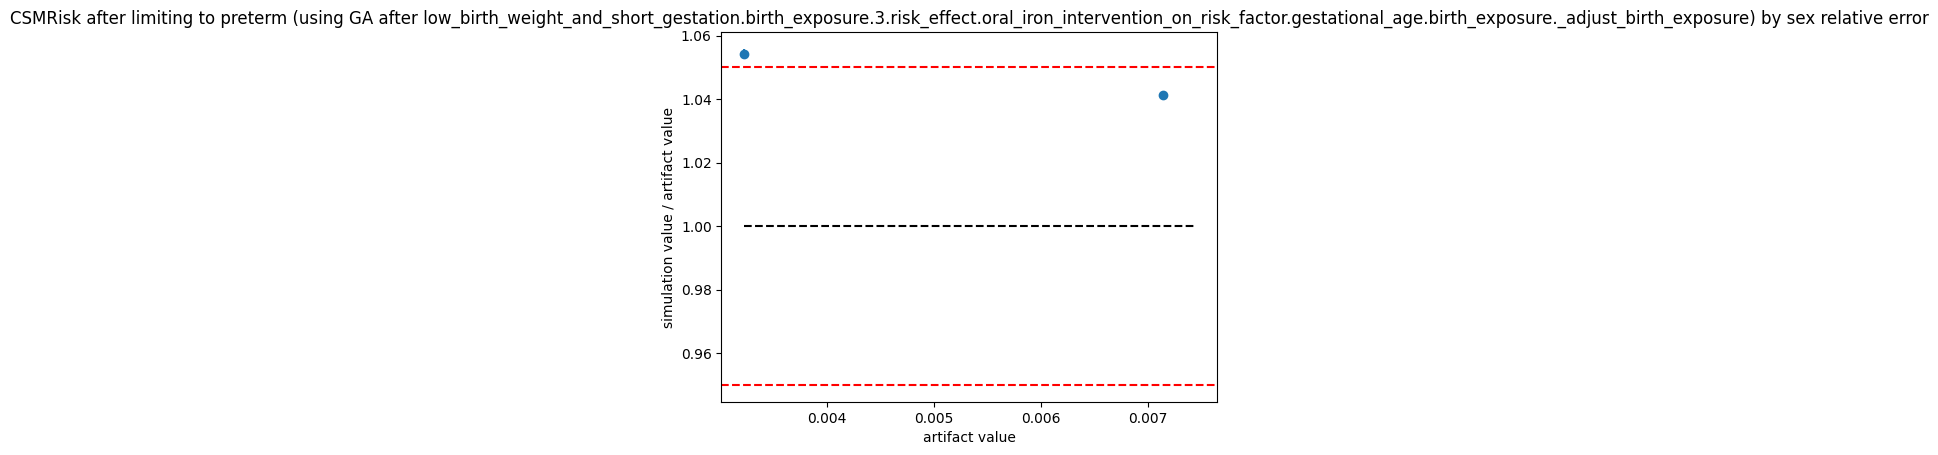

sex_of_child
Female    0.003404
Male      0.007441
Name: value, dtype: float64

Targets


sex_of_child
Female    0.002744
Male      0.006075
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.002893,0.006959,0.0,0.0,0.0,0.0,0.019631
Male,2820853.0,0.006325,0.012699,0.0,0.0,0.0,0.0,0.031820


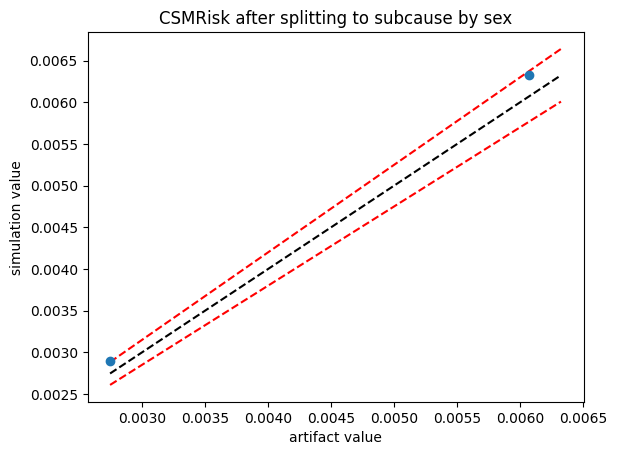

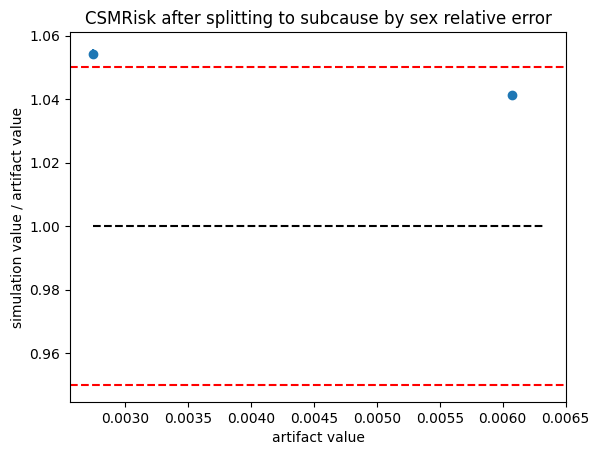

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.002811,0.014682,0.0,0.0,0.0,0.0,0.257446
Male,2820853.0,0.006237,0.024437,0.0,0.0,0.0,0.0,0.328332


Targets


sex_of_child
Female    0.002744
Male      0.006075
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.002811,0.014682,0.0,0.0,0.0,0.0,0.257446
Male,2820853.0,0.006237,0.024437,0.0,0.0,0.0,0.0,0.328332


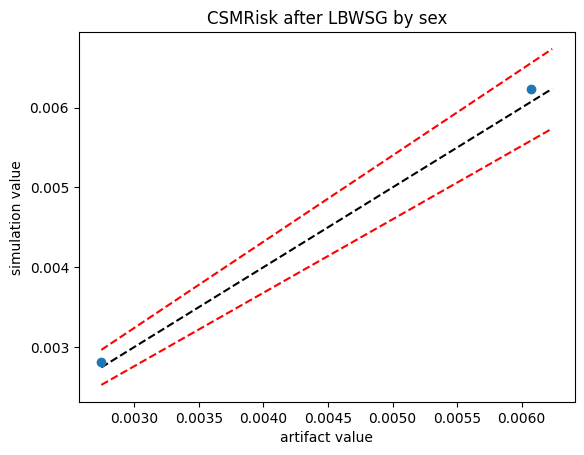

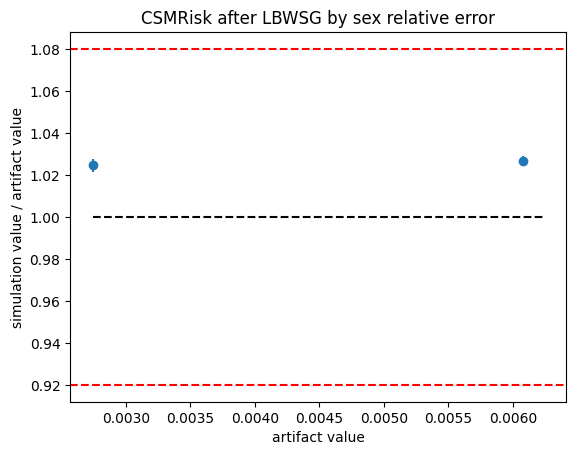

Mutators:


['neonatal_preterm_birth_with_rds.csmr.1.cpap_and_acs_risk_effect.modify_target_pipeline']

After neonatal_preterm_birth_with_rds.csmr.1.cpap_and_acs_risk_effect.modify_target_pipeline


Targets


sex_of_child
Female    0.002744
Male      0.006075
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.002837,0.015421,0.0,0.0,0.0,0.0,0.291151
Male,2820853.0,0.006280,0.025699,0.0,0.0,0.0,0.0,0.371317


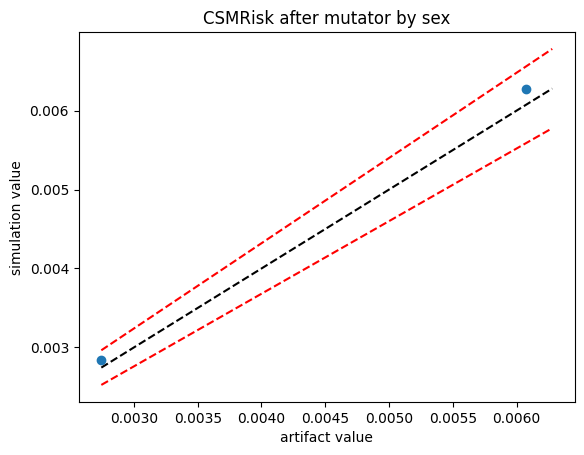

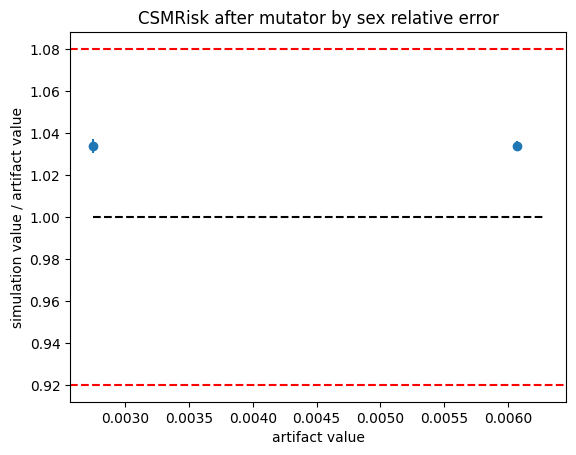

neonatal_preterm_birth_without_rds
Initial cause-specific mortality risk


sex_of_child
Female    0.003228
Male      0.007147
Name: value, dtype: float64

Preterm prevalence target:


sex_of_child
Female    0.139787
Male      0.190916
Name: value, dtype: float64

Initial preterm prevalence based on LBWSG pipeline source:


sex_of_child
Female    0.140179
Male      0.190752
Name: gestational_age, dtype: float64

Targets


sex_of_child
Female    0.003228
Male      0.007147
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.003237,0.008018,0.0,0.0,0.0,0.0,0.023095
Male,2820853.0,0.007141,0.014708,0.0,0.0,0.0,0.0,0.037435


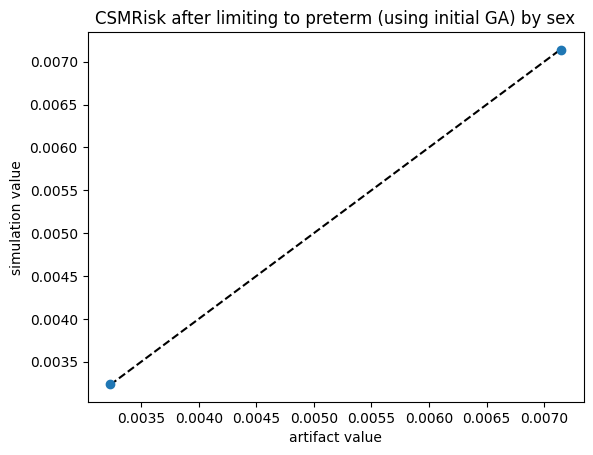

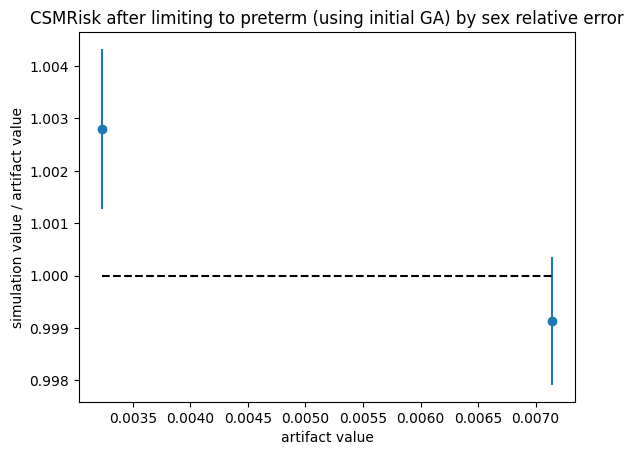

GA mutators:


After low_birth_weight_and_short_gestation.birth_exposure.3.risk_effect.oral_iron_intervention_on_risk_factor.gestational_age.birth_exposure._adjust_birth_exposure, preterm prevalence:


sex_of_child
Female    0.147373
Male      0.198782
Name: gestational_age, dtype: float64

Targets


sex_of_child
Female    0.003228
Male      0.007147
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.003404,0.008187,0.0,0.0,0.0,0.0,0.023095
Male,2820853.0,0.007441,0.014940,0.0,0.0,0.0,0.0,0.037435


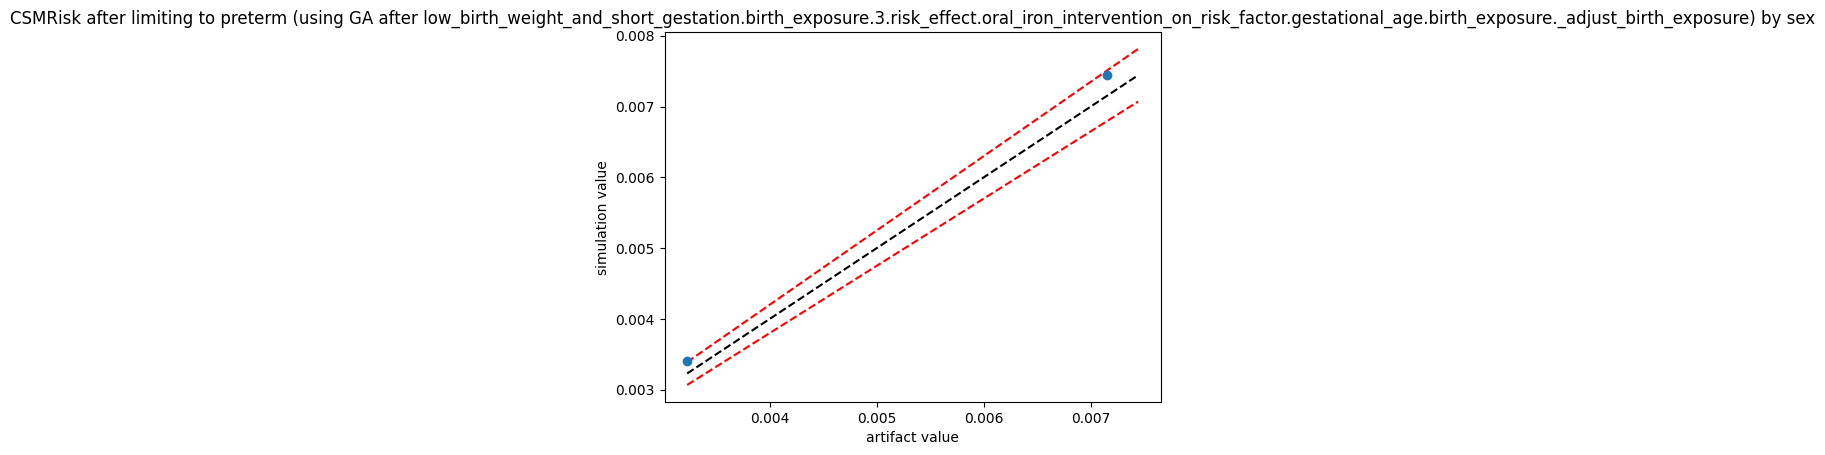

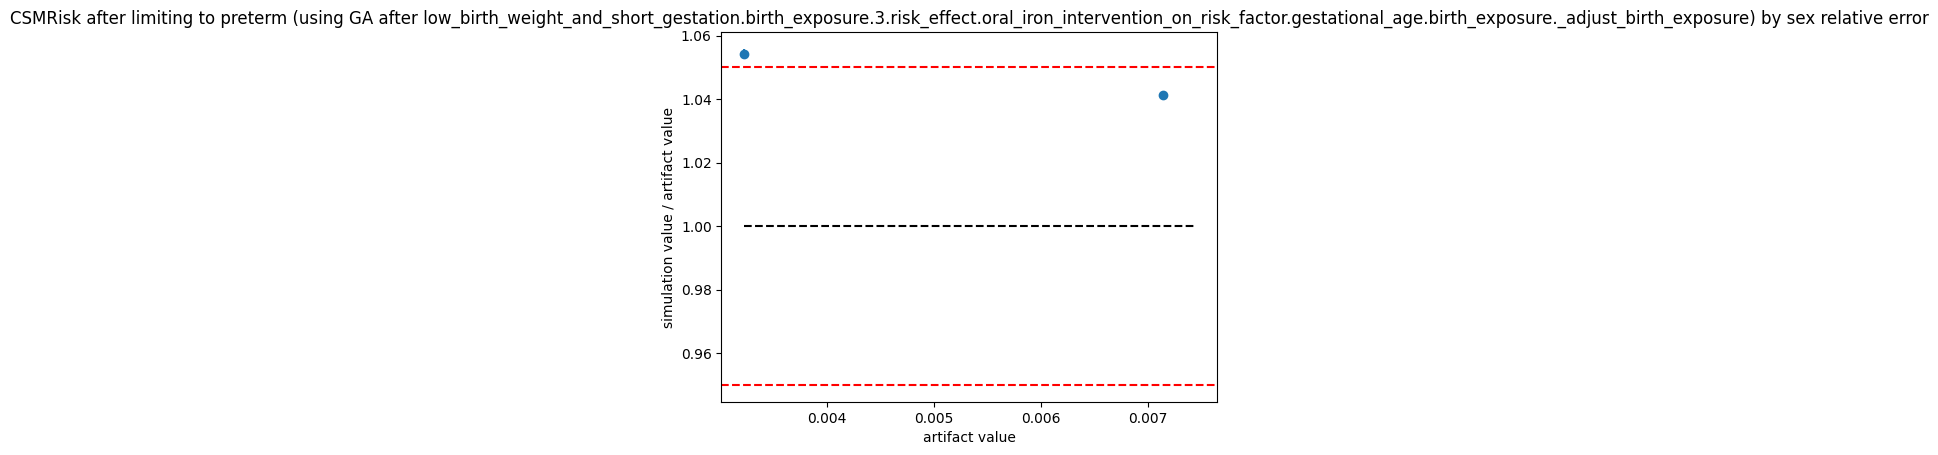

sex_of_child
Female    0.003404
Male      0.007441
Name: value, dtype: float64

Targets


sex_of_child
Female    0.000484
Male      0.001072
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.000511,0.001228,0.0,0.0,0.0,0.0,0.003464
Male,2820853.0,0.001116,0.002241,0.0,0.0,0.0,0.0,0.005615


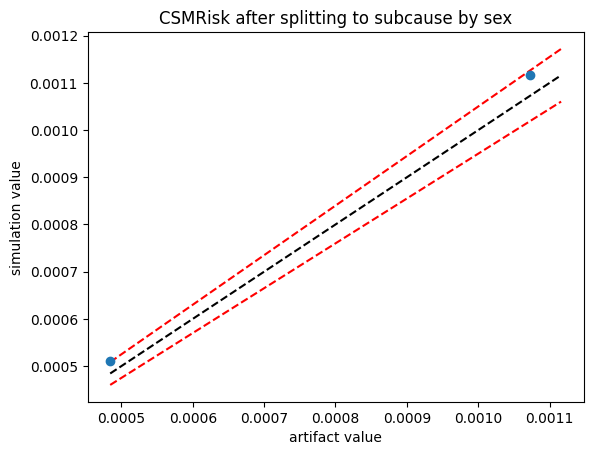

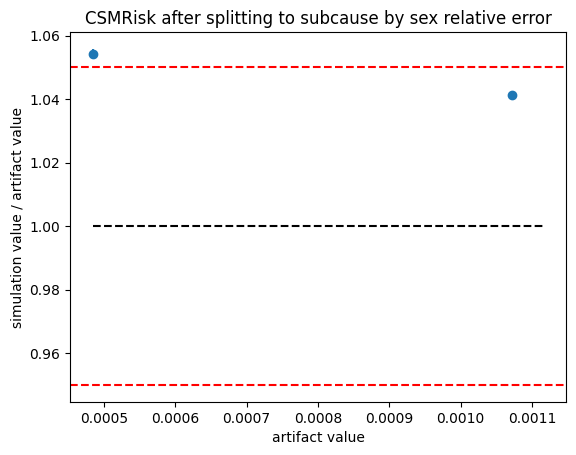

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.000496,0.002591,0.0,0.0,0.0,0.0,0.045432
Male,2820853.0,0.001101,0.004312,0.0,0.0,0.0,0.0,0.057941


Targets


sex_of_child
Female    0.000484
Male      0.001072
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.000496,0.002591,0.0,0.0,0.0,0.0,0.045432
Male,2820853.0,0.001101,0.004312,0.0,0.0,0.0,0.0,0.057941


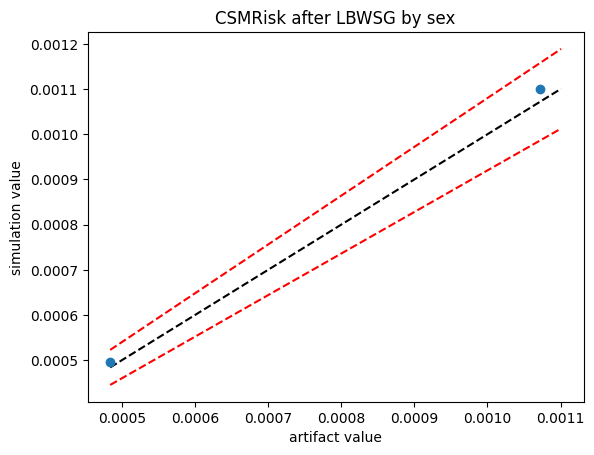

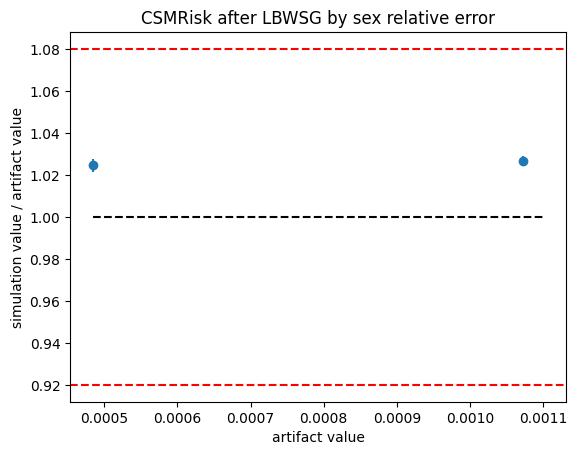

Mutators:


[]

In [50]:
for cause_name in NEONATAL_CAUSES:
    if cause_name == 'neonatal_preterm_birth':
        continue
    print(cause_name)
    step_by_step_check_csmrisk(cause_name, 0, LATE_NEONATAL_AGE_START)

## LNN mortality

### Step main sim to LNN mortality

In [51]:
get_event_name = main_sim._builder.time.simulation_event_name()
get_event_name()

'early_neonatal_mortality'

In [52]:
%%time

while get_event_name() != 'late_neonatal_mortality':
    main_sim.step()
    print(get_event_name())

2026-06-16 17:44:04.970 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2025-01-19 00:00:00


late_neonatal_mortality
CPU times: user 17min 21s, sys: 18min 55s, total: 36min 17s
Wall time: 36min 3s


In [53]:
assert get_event_name() == 'late_neonatal_mortality'

In [54]:
# Just a quick check on the ENN ACMRisk that was actually *observed*
assert (
    main_sim.get_results()['neonatal_acmrisk_sum'].query("child_age_group == 'early_neonatal'").groupby('child_sex').value.sum()
    /
    main_sim.get_results()['neonatal_acmrisk_count'].query("child_age_group == 'early_neonatal'").groupby('child_sex').value.sum()
).equals(mortality_risk.groupby(pop.sex_of_child).mean())

In [ ]:
# We now step to the *middle* of a time step
# https://github.com/ihmeuw/vivarium/blob/aeaa9e03ecbf67929a1ce94e934c2c14ececfa29/src/vivarium/framework/engine.py#L260-L268
self = main_sim
for event in self.time_step_events:
    self._lifecycle.set_state(event)
    pop_to_update = self._clock.get_active_simulants(
        self.get_population_index(),
        self._clock.event_time,
    )
    # https://github.com/ihmeuw/vivarium/blob/aeaa9e03ecbf67929a1ce94e934c2c14ececfa29/src/vivarium/framework/event.py#L119-L141
    clock = self._events.clock()
    step_size = self._events.step_size()
    event_time = clock + step_size

    e = Event(
        "time_step",
        pop_to_update,
        {},
        event_time,
        step_size,
    )

    listener = None
    listeners = self.time_step_emitters[event].__self__.listeners
    for priority_bucket in listeners:
        for listener in priority_bucket:
            if listener.__self__.__class__.__name__ == "NeonatalMortality" and event == "time_step":
                break
            listener(e)
        if listener is not None and listener.__self__.__class__.__name__ == "NeonatalMortality" and event == "time_step":
            break

    if listener is not None and listener.__self__.__class__.__name__ == "NeonatalMortality" and event == "time_step":
        break

In [ ]:
assert listener.__self__.__class__.__name__ == "NeonatalMortality" and event == "time_step"

In [ ]:
pop = main_sim.get_population([
    "child_alive",
    "child_age",
])
assert (pop[pop.child_alive == True].child_age >= LATE_NEONATAL_AGE_START).all()
assert (pop[pop.child_alive == True].child_age < LATE_NEONATAL_AGE_END).all()

In [ ]:
alive_idx = pop.index[pop['child_alive'] == True]

### Feed ENN PAFs back into the PAF sim

In [ ]:
acmr_paf_components = [k for k in paf_sim_components if 'risk_effect.low_birth_weight_' in k]
acmr_paf_components

In [ ]:
for component in acmr_paf_components:
    update_lookup_table(paf_sim_components[component].paf_table, acmrisk_pafs)

In [ ]:
# Check that our transfer actually worked
assert (
    set(paf_sim.get_population("all_causes.all_cause_mortality_risk.paf").loc[paf_sim.get_population("child_alive")])
    <=
    set(acmrisk_pafs['value'].unique())
)

### Step PAF sim to LNN

In [ ]:
%%time

assert (paf_sim.get_population("child_age") < LATE_NEONATAL_AGE_START).all()
paf_sim.step()

In [ ]:
paf_sim_pop = paf_sim.get_population([
    "child_alive",
    "child_age",
])
assert (paf_sim_pop[paf_sim_pop.child_alive == True].child_age >= LATE_NEONATAL_AGE_START).all()
assert (paf_sim_pop[paf_sim_pop.child_alive == True].child_age < LATE_NEONATAL_AGE_END).all()

### Transfer PAFs and preterm prevalence to main sim

In [ ]:
paf_observer = paf_sim_components['lbwsgpaf_observer.cause.all_causes.all_cause_mortality_risk']

In [ ]:
paf_sim._results.gather_results(Event(
    "time_step",
    index=paf_sim.get_population_index(),
    user_data={},
    time=paf_sim._clock.time,
    step_size=paf_sim._clock.step_size,
))

In [ ]:
acmrisk_pafs = process_pafs(
    paf_sim.get_results()['calculated_lbwsg_paf_on_cause.all_causes.all_cause_mortality_risk']
)
acmrisk_pafs

In [ ]:
preterm_csmr_pafs = process_pafs(
    paf_sim.get_results()['calculated_lbwsg_paf_on_cause.all_causes.all_cause_mortality_risk_preterm']
)
preterm_csmr_pafs

In [ ]:
acmr_paf_components = [k for k in main_sim_components if 'risk_effect.low_birth_weight_' in k and 'preterm' not in k]
acmr_paf_components

In [ ]:
for component in acmr_paf_components:
    update_lookup_table(main_sim_components[component].paf_table, acmrisk_pafs)

In [ ]:
preterm_paf_components = [k for k in main_sim_components if ('risk_effect.low_birth_weight_' in k and 'preterm' in k) or ('preterm_birth.' in k)]
preterm_paf_components

In [ ]:
for component in preterm_paf_components:
    update_lookup_table(main_sim_components[component].paf_table, preterm_csmr_pafs)

In [ ]:
late_neonatal_preterm_prevalence = paf_sim.get_results()['calculated_late_neonatal_preterm_prevalence'].assign(
    child_age_start=LATE_NEONATAL_AGE_START,
    child_age_end=LATE_NEONATAL_AGE_END,
    year_start=2023,
    year_end=2024,
).rename(columns={"child_sex": "sex_of_child"})
late_neonatal_preterm_prevalence

In [ ]:
preterm_prevalence_components = [k for k in main_sim_components if 'preterm_birth.' in k]

for component in preterm_prevalence_components:
    lookup_table = main_sim_components[component].prevalence_table
    enn_data = lookup_table.data[lookup_table.data.child_age_start == 0]
    update_lookup_table(lookup_table, pd.concat([enn_data, late_neonatal_preterm_prevalence], ignore_index=True))

In [ ]:
assert (
    set(main_sim_components['preterm_birth.neonatal_preterm_birth_with_rds'].prevalence_table(alive_idx).unique())
    <=
    set(late_neonatal_preterm_prevalence['value'].unique())
)

### Check all-cause mortality risk

In [ ]:
# Check that our transfer above actually worked
assert (
    set(main_sim.get_population("all_causes.all_cause_mortality_risk.paf").unique())
    <=
    set(acmrisk_pafs['value'].unique())
)

In [ ]:
# https://github.com/ihmeuw/vivarium_gates_mncnh/blob/9502fba51790f522523b8cd2925e539a692babf6/src/vivarium_gates_mncnh/components/mortality.py#L281-L283
pop = main_sim.get_population([
    "child_alive",
    "sex_of_child",
    "pregnancy_outcome",
    "effect_of_low_birth_weight_and_short_gestation_on_early_neonatal_all_causes_relative_risk",
    "effect_of_low_birth_weight_and_short_gestation_on_late_neonatal_all_causes_relative_risk"
])
alive_idx = pop.index[pop['child_alive'] == True]
mortality_risk = main_sim.get_population("death_in_age_group_probability").loc[alive_idx]

In [ ]:
acmrisk_targets = get_acmrisk_targets(LATE_NEONATAL_AGE_START, LATE_NEONATAL_AGE_END)
acmrisk_targets

In [ ]:
fuzzy_check(mortality_risk, acmrisk_targets, "late neonatal all-cause mortality risk", acceptable_deviation=0.01)

#### Check individual steps in calculation of all-cause mortality risk

In [ ]:
step_by_step_check_acmrisk(LATE_NEONATAL_AGE_START, LATE_NEONATAL_AGE_END)

### Check cause-specific mortality risks

In [ ]:
# Check that our transfer above actually worked
assert (
    set(main_sim.get_population("all_causes.all_cause_mortality_risk.paf").loc[alive_idx].unique())
    <=
    set(acmrisk_pafs['value'].unique())
)

In [ ]:
# Check that our transfer above actually worked
assert (
    set(main_sim_components['preterm_birth.neonatal_preterm_birth_with_rds'].lbwsg_acmr_paf(main_sim.get_population_index()).unique())
    <=
    set(preterm_csmr_pafs['value'].unique())
)

In [ ]:
check_csmrisks(LATE_NEONATAL_AGE_START, LATE_NEONATAL_AGE_END)

#### Check frequency of negative other-causes mortality, and impact

This isn't the best check because it is only for a single draw and location. In the one I've chosen, this rarely happens, apparently.

In [ ]:
csmrisk_pipeline_names = result = sorted({item for values in CAUSE_NAME_TO_CSMRISK_PIPELINES.values() for item in values})
csmrisk_pipeline_names

In [ ]:
total_csmrisk = 0

for pipeline_name in csmrisk_pipeline_names:
    total_csmrisk += (
        main_sim.get_population(pipeline_name).loc[alive_idx].rename('total_csmrisk')
    )

total_csmrisk

In [ ]:
total_csmrisk.describe()

In [ ]:
(total_csmrisk > mortality_risk).mean()

In [ ]:
# Expect CSMRisks to be underestimated by this amount as a result
(total_csmrisk - mortality_risk).clip(0).sum() / total_csmrisk.sum()

#### Check individual steps in calculation of cause-specific mortality risks

In [ ]:
for cause_name in NEONATAL_CAUSES:
    if cause_name == 'neonatal_preterm_birth':
        continue
    print(cause_name)
    step_by_step_check_csmrisk(cause_name, LATE_NEONATAL_AGE_START, LATE_NEONATAL_AGE_END)

In [ ]:
assert not any_failures

In [ ]:
!date